In [1]:
# %%
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Set standard plotting style
plt.style.use('ggplot')
sns.set_palette("muted")

# ---------------------------------------------------------
# Define input pairs here. 
# ---------------------------------------------------------
input_pairs = [
    # {
    #     "model_name": "DSV4_TFOld",
    #     "result_file": "result/iacgod/NeoDPIaCEval_TF_DeepseekV4Flash_security_runs.csv",
    #     "coverage_file": "result/iacgod/Coverage_DSV4_TF_Sec.csv"
    # },
    # {
    #     "model_name": "DSV4_TFEval",
    #     "result_file": "result/iacgod/TFEval_DeepseekV4Flash_security_runs.csv",
    #     "coverage_file": "result/iacgod/Coverage_DSV4_TFEval_Sec.csv"
    # },
    {
        "model_name": "DSV4_TFEvalV2",
        "result_file": "result/iacgod/TFEvalV2_DeepseekV4Flash_security_runs.csv",
        "coverage_file": "result/iacgod/Coverage_DSV4_TFEvalV2_Sec.csv"
    },
    {
        "model_name": "DSV4_TFEvalRealAWS",
        "result_file": "result/iacgod/TFEvalRealAWS_DeepseekV4Flash_security_runs.csv",
        "coverage_file": "result/iacgod/Coverage_DSV4_TFEvalRealAWS_Sec.csv"
    }
]

In [2]:
merged_dataframes = {}

for pair in input_pairs:
    model = pair["model_name"]
    res_df = pd.read_csv(pair["result_file"])
    cov_df = pd.read_csv(pair["coverage_file"])

    # Merge based on ground_truth_path (or row_number for legacy CFN)
    merge_key = "ground_truth_path" if "ground_truth_path" in cov_df.columns else "row_number"
    
    cols_to_use = cov_df.columns.difference(res_df.columns).tolist() + [merge_key]
    merged_df = pd.merge(res_df, cov_df[cols_to_use], on=merge_key, how="left")

    # Normalize difficulty dtype once, here -- different models' source CSVs can
    # carry difficulty as int64 in one and float64 in another (e.g. 3 vs 3.0).
    # Every downstream cell that does str(diff) for a hue/x-axis label would
    # otherwise treat '3' and '3.0' as two different categories once two such
    # models are compared side by side, silently doubling the apparent number
    # of difficulty levels (and breaking anything sized off that count, like
    # the Pass@N cell's `markers` list -> KeyError). Int64 (nullable) keeps
    # NaNs safe while making every model's difficulty stringify identically.
    for _dc in ["difficulty_level", "difficulty"]:
        if _dc in merged_df.columns:
            merged_df[_dc] = pd.to_numeric(merged_df[_dc], errors="coerce").astype("Int64")

    merged_dataframes[model] = merged_df

    print(f"✅ Successfully merged {len(merged_df)} rows for {model} (Key: {merge_key}).")

✅ Successfully merged 149 rows for DSV4_TFEvalV2 (Key: ground_truth_path).
✅ Successfully merged 150 rows for DSV4_TFEvalRealAWS (Key: ground_truth_path).


📊 Overall Pass Rates:
  -> DSV4_TFEvalV2: 147/149 (98.7%)
  -> DSV4_TFEvalRealAWS: 132/150 (88.0%)


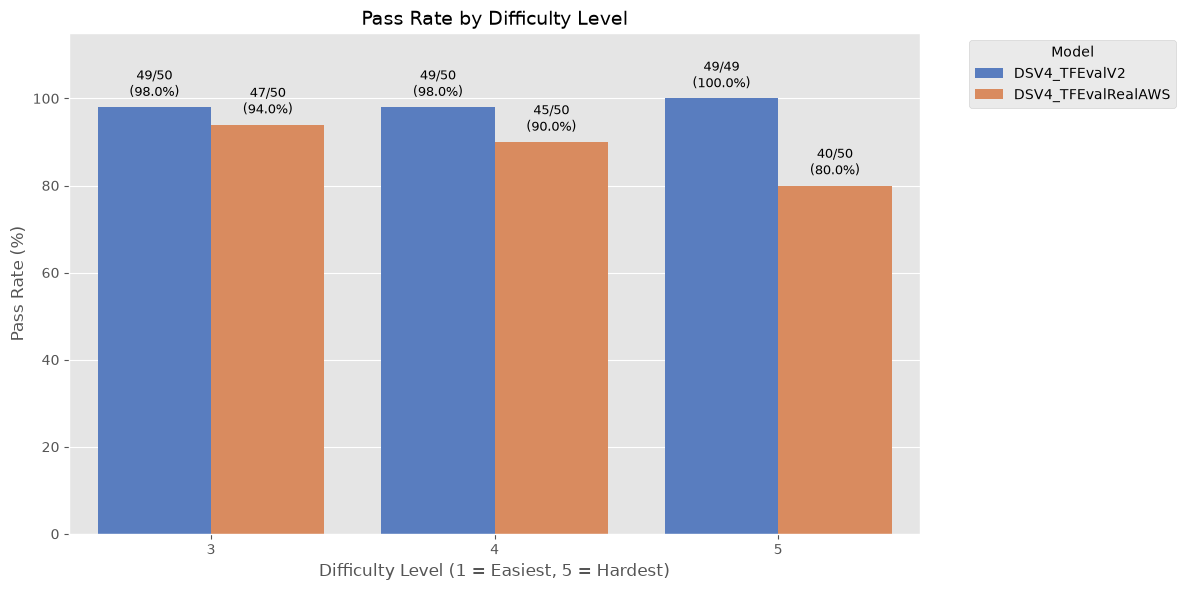

In [3]:
# %%
# ── 1. Pass Rate by Difficulty ────────────────────────────────────────────────
difficulty_stats = []

print("📊 Overall Pass Rates:")
for model_name, df in merged_dataframes.items():
    diff_col = 'difficulty_level' if 'difficulty_level' in df.columns else 'difficulty'
    val_col = 'final_validation_passed' if 'final_validation_passed' in df.columns else ('deploy_pass' if 'deploy_pass' in df.columns else None)

    if diff_col in df.columns and val_col in df.columns:
        # Calculate overall pass rate
        total_passed = int(df[val_col].sum())
        total_scenarios = len(df)
        overall_rate = (total_passed / total_scenarios * 100) if total_scenarios > 0 else 0
        print(f"  -> {model_name}: {total_passed}/{total_scenarios} ({overall_rate:.1f}%)")

        # Calculate pass rate per difficulty
        grouped = df.groupby(diff_col)[val_col].agg(['sum', 'count', 'mean'])
        
        for diff, row in grouped.iterrows():
            passed_cnt = int(row['sum'])
            total_cnt = int(row['count'])
            rate = row['mean'] * 100
            
            difficulty_stats.append({
                'Model': model_name,
                'Difficulty Level': diff,
                'Passed': passed_cnt,
                'Total': total_cnt,
                'Pass Rate (%)': rate
            })

if difficulty_stats:
    diff_df = pd.DataFrame(difficulty_stats)
    
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=diff_df, x='Difficulty Level', y='Pass Rate (%)', hue='Model')
    
    plt.title('Pass Rate by Difficulty Level', fontsize=14)
    plt.ylim(0, 115)  # Increased ylim to accommodate the text labels
    plt.xlabel('Difficulty Level (1 = Easiest, 5 = Hardest)')
    plt.ylabel('Pass Rate (%)')
    
    # Move legend outside to prevent overlap with text
    plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Add labels to the top of each bar
    for i, container in enumerate(ax.containers):
        # Each container represents a hue (Model)
        model_name = ax.get_legend().get_texts()[i].get_text()
        
        for j, p in enumerate(container):
            height = p.get_height()
            if pd.isna(height) or (height == 0 and p.get_y() == 0):
                continue  # Skip empty bars
                
            # The x-tick label corresponds to the difficulty level
            diff_level = ax.get_xticklabels()[j].get_text()
            
            # Retrieve the exact counts from our dataframe
            row = diff_df[(diff_df['Model'] == model_name) & (diff_df['Difficulty Level'].astype(str) == diff_level)]
            
            if not row.empty:
                passed = row['Passed'].values[0]
                total = row['Total'].values[0]
                rate = row['Pass Rate (%)'].values[0]
                
                label_text = f"{passed}/{total}\n({rate:.1f}%)"
                
                # Annotate the bar
                ax.annotate(label_text, 
                            (p.get_x() + p.get_width() / 2., height), 
                            ha='center', va='bottom', 
                            xytext=(0, 5), textcoords='offset points',
                            fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Could not find difficulty or validation columns to plot Pass Rate.")

📊 Calculating Cumulative Pass Rates by Iteration Milestones...


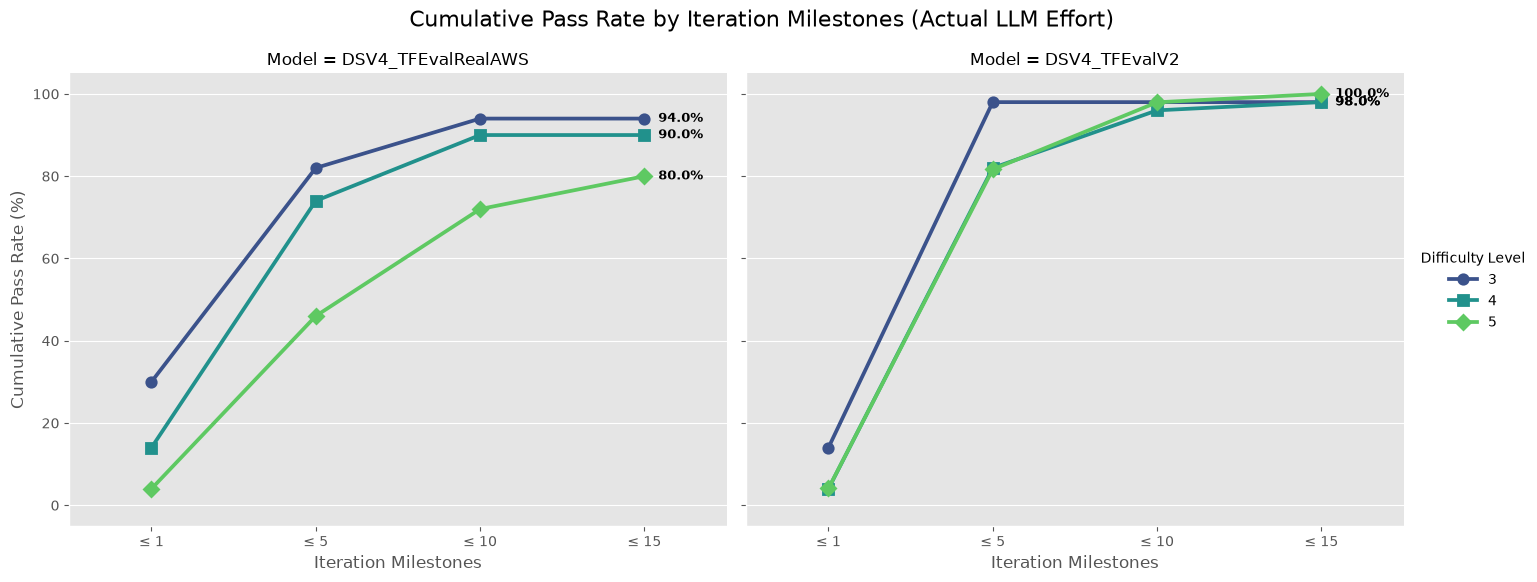

In [4]:

# ── 1b. Pass@N (cumulative pass rate by iteration budget) ─────────────────────
# pass@N here means: of all scenarios, what fraction ultimately passed AND did
# so within N iterations of the generate/validate/repair loop -- i.e. "if we'd
# capped the agent's iteration budget at N, what pass rate would we still see."
target_iterations = [1, 5, 10, 15]
iteration_stats = []

print("📊 Calculating Cumulative Pass Rates by Iteration Milestones...")
for model_name, df in merged_dataframes.items():
    diff_col = 'difficulty_level' if 'difficulty_level' in df.columns else 'difficulty'
    val_col = 'final_validation_passed' if 'final_validation_passed' in df.columns else ('deploy_pass' if 'deploy_pass' in df.columns else None)
    iter_col = 'iterations_used'

    if diff_col in df.columns and val_col in df.columns and iter_col in df.columns:
        # Ensure we're working with clean numeric data for iterations
        df[iter_col] = pd.to_numeric(df[iter_col], errors='coerce')
        
        for diff in sorted(df[diff_col].dropna().unique()):
            subset = df[df[diff_col] == diff]
            total_in_diff = len(subset)

            if total_in_diff == 0:
                continue

            for t_iter in target_iterations:
                # Condition: The generation ultimately passed AND it took <= N iterations
                passed_subset = subset[(subset[val_col] == 1) & (subset[iter_col] <= t_iter)]
                pass_rate = (len(passed_subset) / total_in_diff) * 100

                iteration_stats.append({
                    'Model': model_name,
                    'Difficulty Level': str(diff), # Convert to string for discrete legend
                    'Iteration Limit': f'≤ {t_iter}',
                    'Iteration_Num': t_iter, # Used purely for chronological sorting
                    'Pass Rate (%)': pass_rate
                })
    else:
        print(f"⚠️ Missing required columns for model {model_name}. Need difficulty, validation, and 'iterations_used'.")

if iteration_stats:
    iter_df = pd.DataFrame(iteration_stats).sort_values(by=['Model', 'Difficulty Level', 'Iteration_Num'])

    # Create a point plot to show progression over time (iterations)
    g = sns.catplot(
        data=iter_df, 
        kind="point",
        x="Iteration Limit", 
        y="Pass Rate (%)", 
        hue="Difficulty Level", 
        col="Model",
        palette="viridis", 
        height=5.5, 
        aspect=1.3,
        markers=["o", "s", "D", "^", "v"][:len(iter_df['Difficulty Level'].unique())],
        linestyles="-"
    )

    g.set_axis_labels("Iteration Milestones", "Cumulative Pass Rate (%)")
    g.set(ylim=(-5, 105))
    g.fig.suptitle('Cumulative Pass Rate by Iteration Milestones (Actual LLM Effort)', fontsize=16, y=1.05)

    # Add data labels for the final iteration milestone (15) to show the plateau ceiling
    for ax in g.axes.flat:
        for line in ax.lines:
            # Only label the last point (Iteration <= 15) for cleaner visuals
            if len(line.get_xdata()) > 0:
                x_last = line.get_xdata()[-1]
                y_last = line.get_ydata()[-1]
                if pd.notna(y_last):
                    ax.annotate(
                        f'{y_last:.1f}%', 
                        xy=(x_last, y_last), 
                        xytext=(10, 0),
                        textcoords='offset points',
                        ha='left', va='center',
                        fontsize=9,
                        fontweight='bold'
                    )

    plt.show()
else:
    print("⚠️ No valid data processed for iteration milestones.")

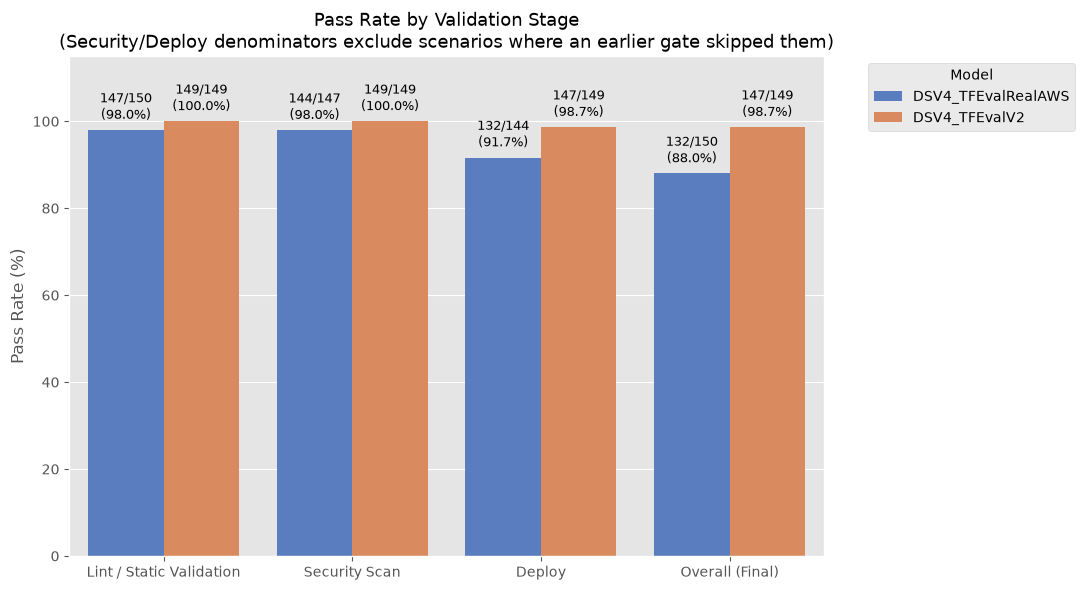

📊 Stage pass rates -- 'Total' is scenarios that actually reached that stage (excludes ones an earlier gate already skipped them past):


,Model,Stage,Passed,Total,Pass Rate (%)
0,DSV4_TFEvalRealAWS,Lint / Static Validation,147,150,98.0
1,DSV4_TFEvalV2,Lint / Static Validation,149,149,100.0
2,DSV4_TFEvalRealAWS,Security Scan,144,147,98.0
3,DSV4_TFEvalV2,Security Scan,149,149,100.0
4,DSV4_TFEvalRealAWS,Deploy,132,144,91.7
5,DSV4_TFEvalV2,Deploy,147,149,98.7
6,DSV4_TFEvalRealAWS,Overall (Final),132,150,88.0
7,DSV4_TFEvalV2,Overall (Final),147,149,98.7


In [5]:
# ── 1c. Pass Rate by Validation Stage ──────────────────────────────────────
# "Pass Rate by Difficulty" (above) asks "does a scenario ultimately pass
# end-to-end". This asks the narrower, per-gate question: of the scenarios
# that actually REACHED each stage, what fraction cleared it.
#
# The pipeline (IaCGOD's tools/validators.py, run_all_validators) gates
# strictly sequentially: Lint (yaml + cfn-lint, always run) -> Security
# (trivy, only run if Lint fully passed) -> Deploy (only run if Lint AND
# Security fully passed). A stage the pipeline skips because an earlier gate
# already failed is deliberately recorded as passed=True with no errors ("a
# skipped stage is not a failed stage — it simply did not run", per the
# source's own comment) precisely so the skip isn't miscounted as a failure
# further up the repair loop. That same convention means a skip must NOT be
# counted as a genuine pass here either -- Security/Deploy's denominator
# below is restricted to rows where the stage actually ran (the earlier
# gate(s) passed), not just "column is non-null".
STAGE_CONFIG = [
    {"key": "tflint",              "label": "TFLint",             "all_col": "all_yaml_errors",     "latest_col": "latest_error_tflint",             "passed_col": "val_stage_tflint_passed"},
    {"key": "terraform-validate",  "label": "terraform validate", "all_col": "all_cfn_lint_errors", "latest_col": "latest_error_terraform-validate", "passed_col": "val_stage_terraform-validate_passed"},
    {"key": "trivy",               "label": "Trivy/Security",     "all_col": "all_security_errors", "latest_col": "latest_error_trivy",              "passed_col": "val_stage_trivy_passed"},
]

lint_keys = [s["key"] for s in STAGE_CONFIG if s["key"] != "trivy"]      # always run
security_keys = [s["key"] for s in STAGE_CONFIG if s["key"] == "trivy"]  # gated by lint_keys
stage_col_map = {s["key"]: s["passed_col"] for s in STAGE_CONFIG}

def stage_rate(df: pd.DataFrame, keys: list, gate_keys: list = None):
    """Pass rate for the stage(s) in `keys`, restricted to rows where the
    stage actually ran -- i.e. every stage in `gate_keys` (if given) passed
    for real. Without this restriction, a skipped stage's passed=True
    placeholder would silently inflate this metric."""
    cols = [stage_col_map[k] for k in keys if stage_col_map[k] in df.columns]
    if not cols:
        return None, None
    reached = df[cols].notna().all(axis=1)
    if gate_keys:
        gate_cols = [stage_col_map[k] for k in gate_keys if stage_col_map[k] in df.columns]
        if gate_cols:
            reached = reached & df[gate_cols].eq(True).all(axis=1)
    passed = reached & df[cols].eq(True).all(axis=1)
    return int(passed.sum()), int(reached.sum())

stage_pass_rows = []
for model_name, df in merged_dataframes.items():
    for label, keys, gate in [
        ("Lint / Static Validation", lint_keys, None),
        ("Security Scan", security_keys, lint_keys),
    ]:
        p, t = stage_rate(df, keys, gate_keys=gate)
        if t:
            stage_pass_rows.append({"Model": model_name, "Stage": label, "Passed": p, "Total": t, "Pass Rate (%)": p / t * 100})

    if "deploy_passed" in df.columns:
        gate_cols = [stage_col_map[k] for k in (lint_keys + security_keys) if stage_col_map[k] in df.columns]
        reached = df[gate_cols].eq(True).all(axis=1) if gate_cols else pd.Series(True, index=df.index)
        if "deploy_target" in df.columns:
            # Ground truth for "did deploy actually run" -- the pipeline
            # itself stamps `deploy_target == "skipped"` whenever an earlier
            # gate failed, so prefer this over the derived gate when present.
            reached = reached & (df["deploy_target"] != "skipped")
        passed = reached & (df["deploy_passed"] == True)
        t = int(reached.sum())
        if t:
            stage_pass_rows.append({"Model": model_name, "Stage": "Deploy", "Passed": int(passed.sum()), "Total": t, "Pass Rate (%)": passed.sum() / t * 100})

    if "final_validation_passed" in df.columns:
        s = df["final_validation_passed"]
        t = int(s.notna().sum())
        if t:
            stage_pass_rows.append({"Model": model_name, "Stage": "Overall (Final)", "Passed": int((s == True).sum()), "Total": t, "Pass Rate (%)": (s == True).sum() / t * 100})

if stage_pass_rows:
    stage_df = pd.DataFrame(stage_pass_rows)
    stage_order = ["Lint / Static Validation", "Security Scan", "Deploy", "Overall (Final)"]
    stage_df["Stage"] = pd.Categorical(stage_df["Stage"], categories=stage_order, ordered=True)
    stage_df = stage_df.sort_values(["Stage", "Model"])

    plt.figure(figsize=(11, 6))
    ax = sns.barplot(data=stage_df, x="Stage", y="Pass Rate (%)", hue="Model", order=stage_order)
    plt.title("Pass Rate by Validation Stage\n(Security/Deploy denominators exclude scenarios where an earlier gate skipped them)", fontsize=13)
    plt.ylim(0, 115)
    plt.xlabel("")
    plt.ylabel("Pass Rate (%)")
    plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")

    for i, container in enumerate(ax.containers):
        model_name = ax.get_legend().get_texts()[i].get_text()
        for j, p in enumerate(container):
            height = p.get_height()
            if pd.isna(height) or (height == 0 and p.get_y() == 0):
                continue
            stage_label = ax.get_xticklabels()[j].get_text()
            row = stage_df[(stage_df["Model"] == model_name) & (stage_df["Stage"].astype(str) == stage_label)]
            if not row.empty:
                passed = row["Passed"].values[0]
                total = row["Total"].values[0]
                rate = row["Pass Rate (%)"].values[0]
                ax.annotate(f"{passed}/{total}\n({rate:.1f}%)",
                            (p.get_x() + p.get_width() / 2., height),
                            ha="center", va="bottom", xytext=(0, 5),
                            textcoords="offset points", fontsize=9)

    plt.tight_layout()
    plt.show()

    print("📊 Stage pass rates -- 'Total' is scenarios that actually reached that stage "
          "(excludes ones an earlier gate already skipped them past):")
    display(stage_df[["Model", "Stage", "Passed", "Total", "Pass Rate (%)"]]
            .sort_values(["Stage", "Model"]).round(1).reset_index(drop=True))
else:
    print("⚠️ No stage-level pass/fail columns found.")


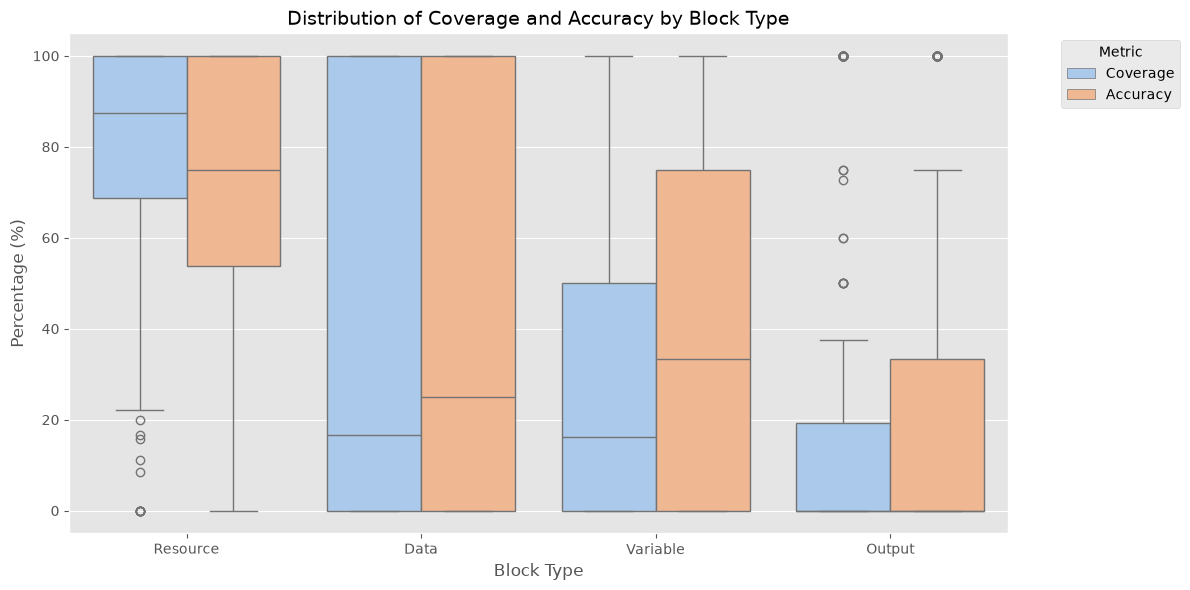

In [6]:
# ── 2. Coverage & Accuracy Distributions by Block Type (Boxplots) ─────────────
box_data = []
block_types = ['resource', 'data', 'variable', 'output']

for model_name, df in merged_dataframes.items():
    # Legacy CFN Support
    if 'coverage_pct' in df.columns:
        for _, row in df.dropna(subset=['coverage_pct', 'accuracy_pct']).iterrows():
            box_data.append({'Model': model_name, 'Block Type': 'Resource', 'Metric': 'Coverage', 'Percentage': row['coverage_pct']})
            box_data.append({'Model': model_name, 'Block Type': 'Resource', 'Metric': 'Accuracy', 'Percentage': row['accuracy_pct']})
    else:
        # New TF Block Types
        for btype in block_types:
            cov_col, acc_col = f'{btype}_cov_pct', f'{btype}_acc_pct'
            if cov_col in df.columns and acc_col in df.columns:
                for _, row in df.dropna(subset=[cov_col, acc_col]).iterrows():
                    box_data.append({'Model': model_name, 'Block Type': btype.capitalize(), 'Metric': 'Coverage', 'Percentage': row[cov_col]})
                    box_data.append({'Model': model_name, 'Block Type': btype.capitalize(), 'Metric': 'Accuracy', 'Percentage': row[acc_col]})

if box_data:
    box_df = pd.DataFrame(box_data)
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=box_df, x='Block Type', y='Percentage', hue='Metric', palette='pastel')
    plt.title('Distribution of Coverage and Accuracy by Block Type', fontsize=14)
    plt.ylabel('Percentage (%)')
    plt.ylim(-5, 105)
    plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

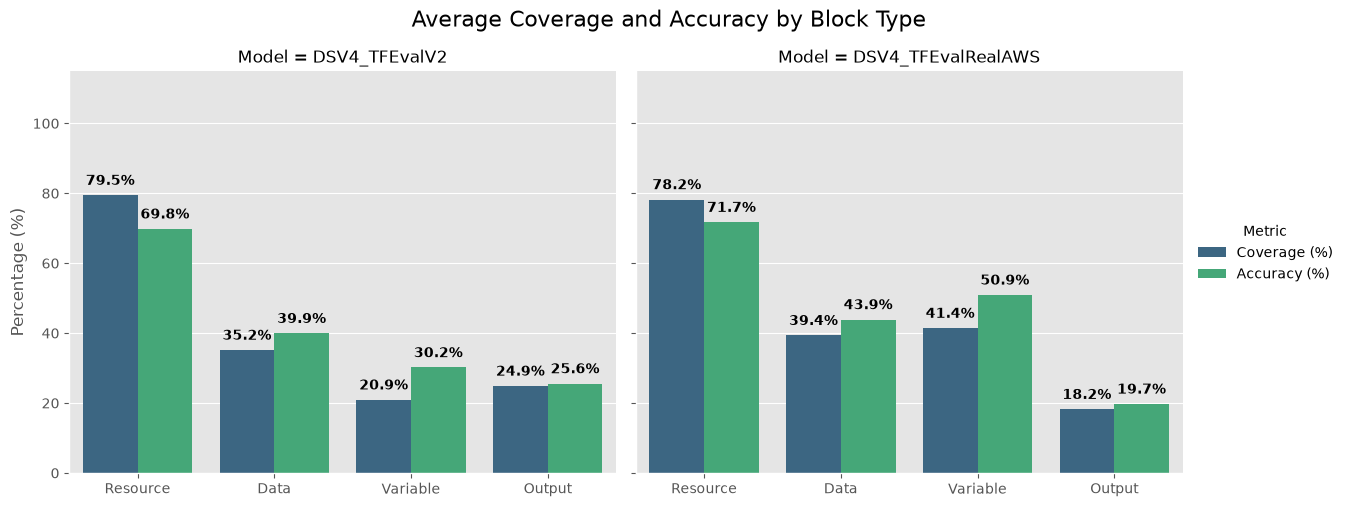

In [7]:
# ── 3. Average Coverage and Accuracy Bar Chart (By Block Type) ────────────────
avg_metrics_data = []

for model_name, df in merged_dataframes.items():
    if 'coverage_pct' in df.columns:
        avg_metrics_data.append({'Model': model_name, 'Block Type': 'Resource', 'Metric': 'Coverage (%)', 'Value': df['coverage_pct'].mean()})
        avg_metrics_data.append({'Model': model_name, 'Block Type': 'Resource', 'Metric': 'Accuracy (%)', 'Value': df['accuracy_pct'].mean()})
    else:
        for btype in block_types:
            cov_col, acc_col = f'{btype}_cov_pct', f'{btype}_acc_pct'
            if cov_col in df.columns and acc_col in df.columns:
                avg_metrics_data.append({'Model': model_name, 'Block Type': btype.capitalize(), 'Metric': 'Coverage (%)', 'Value': df[cov_col].mean()})
                avg_metrics_data.append({'Model': model_name, 'Block Type': btype.capitalize(), 'Metric': 'Accuracy (%)', 'Value': df[acc_col].mean()})

if avg_metrics_data:
    avg_df = pd.DataFrame(avg_metrics_data)
    
    # Use catplot to handle single or multiple models elegantly
    g = sns.catplot(
        data=avg_df, kind="bar",
        x="Block Type", y="Value", hue="Metric", col="Model",
        palette="viridis", height=5, aspect=1.2
    )
    
    g.set_axis_labels("", "Percentage (%)")
    g.set(ylim=(0, 115))
    g.fig.suptitle('Average Coverage and Accuracy by Block Type', fontsize=16, y=1.05)

    # Add data labels to bars
    for ax in g.axes.flat:
        for p in ax.patches:
            height = p.get_height()
            if pd.notna(height) and height > 0:
                ax.text(p.get_x() + p.get_width() / 2., height + 2, f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
                
    plt.show()

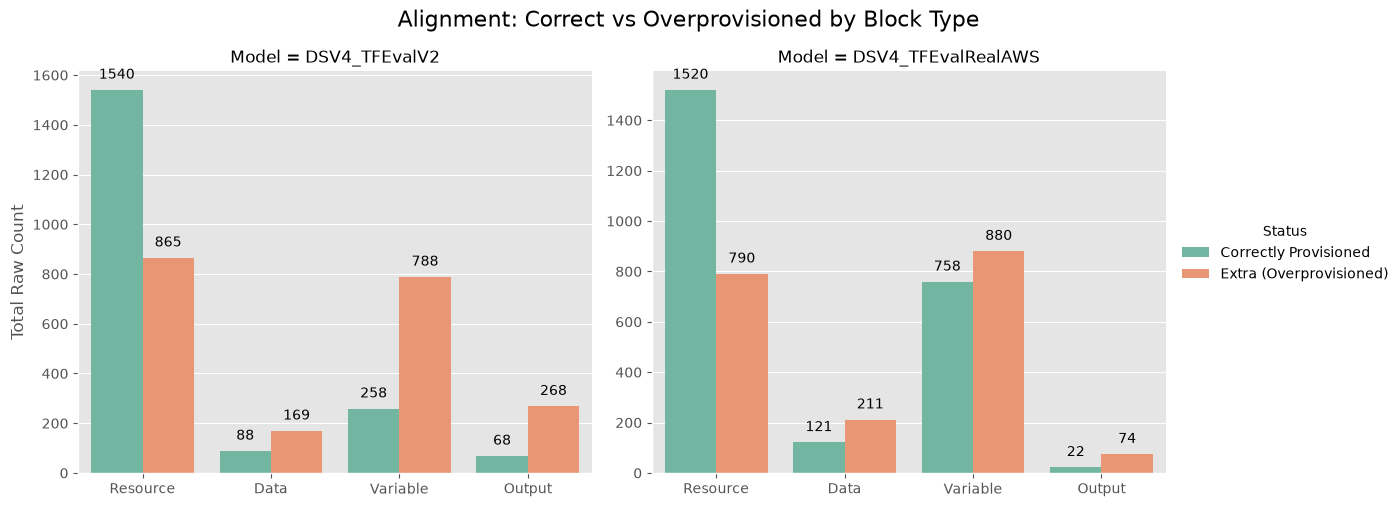

In [8]:
# ── 4. Resource Alignment: Correct vs Overprovisioned (By Block Type) ─────────
overprovisioning_data = []

for model_name, df in merged_dataframes.items():
    if 'correct_resources' in df.columns:
        overprovisioning_data.append({'Model': model_name, 'Block Type': 'Resource', 'Status': 'Correctly Provisioned', 'Total': df['correct_resources'].sum()})
        overprovisioning_data.append({'Model': model_name, 'Block Type': 'Resource', 'Status': 'Extra (Overprovisioned)', 'Total': df['extra_resources'].sum()})
    else:
        for btype in block_types:
            cor_col, ext_col = f'{btype}_cor', f'{btype}_extra'
            if cor_col in df.columns and ext_col in df.columns:
                overprovisioning_data.append({'Model': model_name, 'Block Type': btype.capitalize(), 'Status': 'Correctly Provisioned', 'Total': df[cor_col].sum()})
                overprovisioning_data.append({'Model': model_name, 'Block Type': btype.capitalize(), 'Status': 'Extra (Overprovisioned)', 'Total': df[ext_col].sum()})

if overprovisioning_data:
    over_df = pd.DataFrame(overprovisioning_data)
    
    g = sns.catplot(
        data=over_df, kind="bar",
        x="Block Type", y="Total", hue="Status", col="Model",
        palette="Set2", height=5, aspect=1.2, sharey=False
    )
    
    g.set_axis_labels("", "Total Raw Count")
    g.fig.suptitle('Alignment: Correct vs Overprovisioned by Block Type', fontsize=16, y=1.05)

    for ax in g.axes.flat:
        for p in ax.patches:
            height = p.get_height()
            if pd.notna(height) and height > 0:
                ax.text(p.get_x() + p.get_width() / 2., height + (ax.get_ylim()[1] * 0.02), f'{int(height)}', ha='center', va='bottom', fontsize=10)
                
    plt.show()

/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_89979/257090815.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_missing, y='Resource Type', x='Frequency', palette='Blues_r')


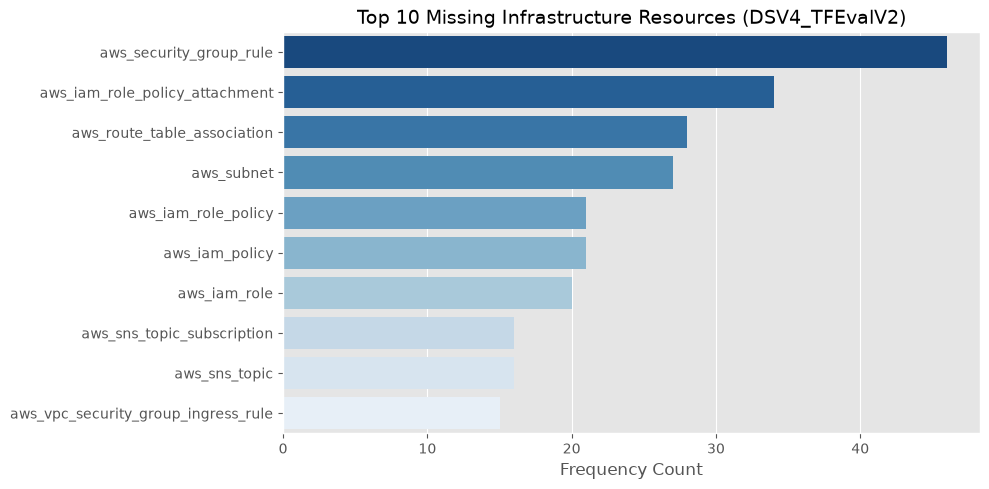

/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_89979/257090815.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_extra, y='Resource Type', x='Frequency', palette='Oranges_r')


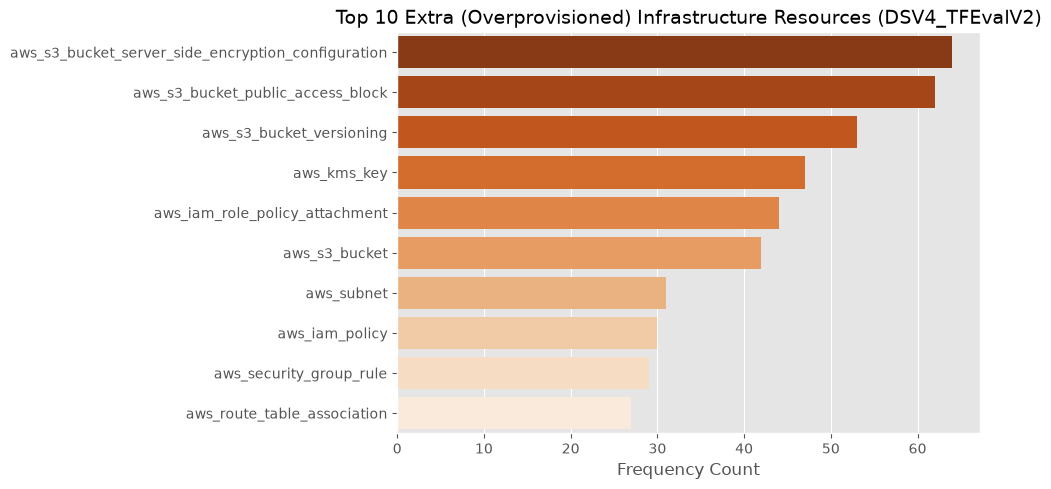

/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_89979/257090815.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_missing, y='Resource Type', x='Frequency', palette='Blues_r')


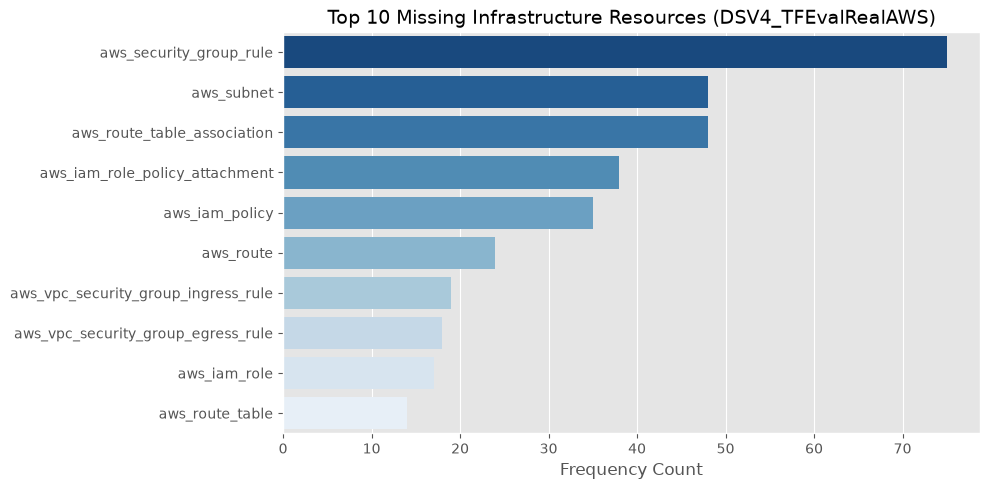

/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_89979/257090815.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_extra, y='Resource Type', x='Frequency', palette='Oranges_r')


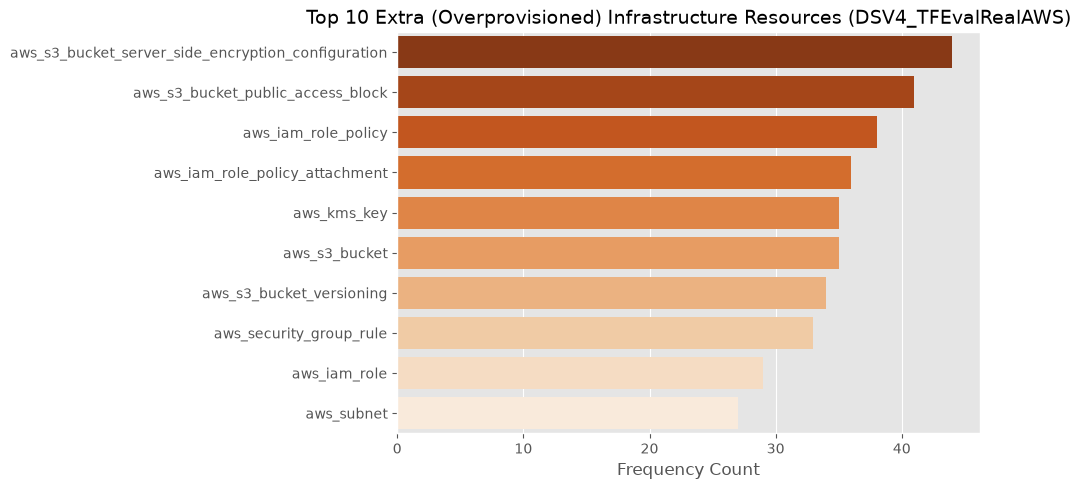

In [9]:
# ── 5. Top Missing and Extra Resource Types ───────────────────────────────────
# Note: We only plot "Resource" types here as variables and outputs usually have 
# arbitrary user-defined names that aren't useful to aggregate in a bar chart.

for model_name, df in merged_dataframes.items():
    missing_counter = Counter()
    extra_counter = Counter()

    missing_col = 'resource_missing_list' if 'resource_missing_list' in df.columns else 'missing_resource_types'
    extra_col = 'resource_extra_list' if 'resource_extra_list' in df.columns else 'extra_resource_types'

    if missing_col in df.columns:
        for items in df[missing_col].dropna():
            for item in str(items).split(';'):
                if item.strip():
                    missing_counter[item.strip()] += 1

    if extra_col in df.columns:
        for items in df[extra_col].dropna():
            for item in str(items).split(';'):
                if item.strip():
                    extra_counter[item.strip()] += 1

    top_missing = pd.DataFrame(missing_counter.most_common(10), columns=['Resource Type', 'Frequency'])
    top_extra = pd.DataFrame(extra_counter.most_common(10), columns=['Resource Type', 'Frequency'])

    if not top_missing.empty:
        plt.figure(figsize=(10, 5))
        sns.barplot(data=top_missing, y='Resource Type', x='Frequency', palette='Blues_r')
        plt.title(f'Top 10 Missing Infrastructure Resources ({model_name})', fontsize=14)
        plt.xlabel('Frequency Count')
        plt.ylabel('')
        plt.tight_layout()
        plt.show()

    if not top_extra.empty:
        plt.figure(figsize=(10, 5))
        sns.barplot(data=top_extra, y='Resource Type', x='Frequency', palette='Oranges_r')
        plt.title(f'Top 10 Extra (Overprovisioned) Infrastructure Resources ({model_name})', fontsize=14)
        plt.xlabel('Frequency Count')
        plt.ylabel('')
        plt.tight_layout()
        plt.show()

In [10]:
df.columns

Index(['row_number', 'ground_truth_path', 'run_id', 'status',
       'final_validation_passed', 'iterations_used', 'llm_calls_total',
       'token_all_tokens', 'token_input_tokens', 'token_output_tokens',
       'token_prompt_tokens', 'token_completion_tokens',
       'scenario_policy_pass_rate', 'filtered_compliance_rate',
       'unfiltered_compliance_rate', 'duration_seconds', 'error_message',
       'error_traceback', 'policy_total_policies', 'policy_passed_policies',
       'final_template', 'deploy_target', 'deploy_passed', 'deploy_stack_id',
       'deploy_error_message', 'deploy_logs', 'deploy_duration_seconds',
       'deploy_failed_resources', 'deploy_completed_resources',
       'total_yaml_errors', 'total_cfn_lint_errors', 'total_security_errors',
       'all_yaml_errors', 'all_cfn_lint_errors', 'all_security_errors',
       'latest_error_tflint', 'latest_error_terraform-validate',
       'latest_error_trivy', 'val_stage_tflint_passed',
       'val_stage_terraform-validate


DSV4_TFEvalV2: 3/149 scenarios (2.0%) below 30% on both coverage and accuracy.
  ⚠️ 3 of those still PASSED final validation despite the drift -- the generated stack was deployable/secure but unrelated to what was asked, which is exactly the failure mode coverage/accuracy scoring exists to catch (final_validation_passed alone would have hidden it).


,row_number,coverage_pct,accuracy_pct,final_validation_passed,ground_truth_path
0,20,0.00,0.00,True,iac_benchmark/scenarios/gh_3a4dde50
1,197,8.57,14.29,True,iac_benchmark/scenarios/terrads_8c3d60955e7f
2,22,25.00,14.29,True,iac_benchmark/scenarios/terrads_8ecc16737478



DSV4_TFEvalRealAWS: 10/150 scenarios (6.7%) below 30% on both coverage and accuracy.
  ⚠️ 9 of those still PASSED final validation despite the drift -- the generated stack was deployable/secure but unrelated to what was asked, which is exactly the failure mode coverage/accuracy scoring exists to catch (final_validation_passed alone would have hidden it).


,row_number,coverage_pct,accuracy_pct,final_validation_passed,ground_truth_path
0,88,0.00,0.00,True,iac_benchmark/scenarios/terrads_e6f040aa6f83
1,129,0.00,0.00,True,iac_benchmark/scenarios/gh_e1731993
2,189,0.00,0.00,True,iac_benchmark/scenarios_greenfield/terrads_ce5484f81fb0
3,191,0.00,0.00,False,iac_benchmark/scenarios/gh_3a4dde50
4,218,0.00,0.00,True,iac_benchmark/scenarios/terrads_319adcef4c22
5,234,0.00,0.00,True,iac_benchmark/scenarios_greenfield/terrads_88dc033be3cb
6,242,0.00,0.00,True,iac_benchmark/scenarios_greenfield/gh_441bac48
7,179,16.67,25.00,True,iac_benchmark/scenarios/gh_7ae21b79
8,209,22.22,7.14,True,iac_benchmark/scenarios/terrads_78b2234acc8f
9,188,25.00,13.04,True,iac_benchmark/scenarios/terrads_83b303c27ebb


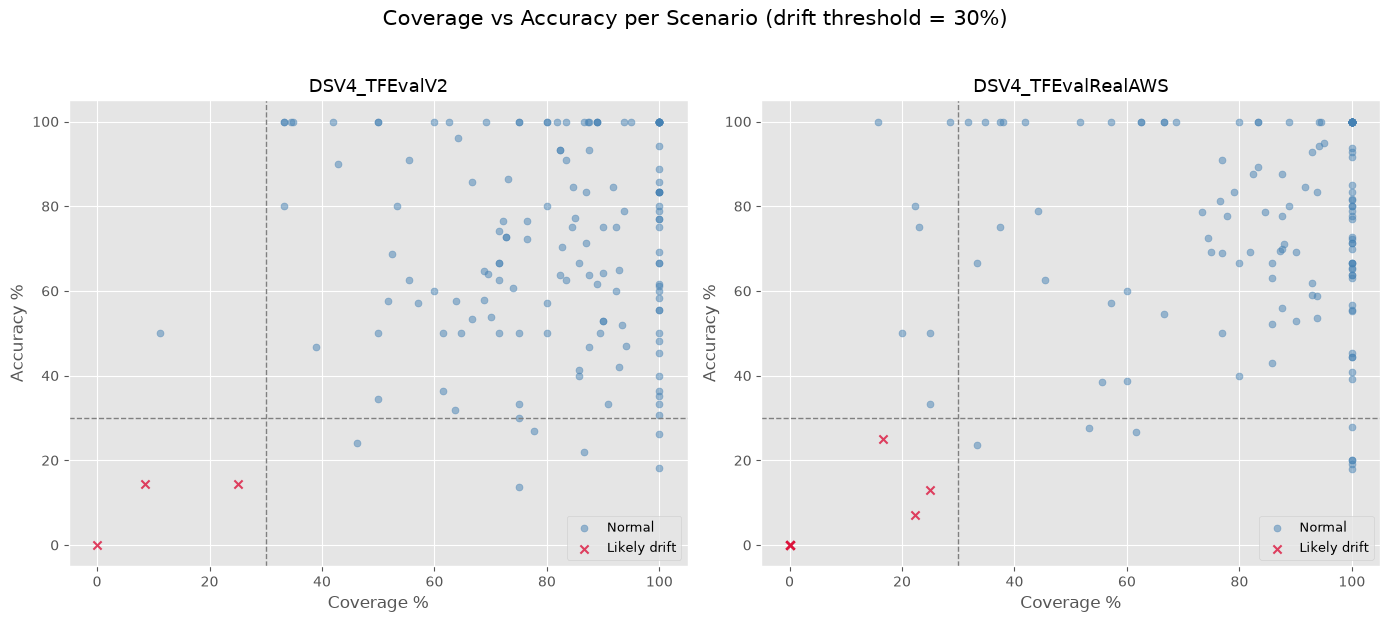

In [11]:
# ── 6. Low Coverage/Accuracy Scenario Audit (possible benchmark problems) ────
# Some rows come back with coverage/accuracy far below the model's typical
# performance even when the run itself completed and validated successfully.
# That pattern is a signal worth distinguishing into two different causes:
#   (a) the LLM genuinely drifted away from the prompt (generated something
#       unrelated), or
#   (b) the benchmark row itself is broken -- e.g. a ground-truth template
#       whose "required resources" can't reasonably be inferred from its own
#       prompt (see the "changed prompts" / "need resampling" notes below
#       from a previous manual pass over this exact symptom: several 0%-
#       coverage rows turned out to be AWS Config conformance-pack templates
#       that assume a Config Recorder/Delivery Channel already exists, or
#       templates built on deprecated resource types like the classic WAF).
# This cell makes that triage repeatable and reusable across all models in
# `input_pairs` instead of a one-off hardcoded printout.

# A scenario is flagged as "likely drift" only when BOTH coverage AND
# accuracy fall below the threshold together. Low coverage alone can mean
# "did the bare minimum but got it right" (e.g. cov=8% acc=100%), and low
# accuracy alone can mean "over-provisioned but covered everything asked"
# (e.g. cov=100% acc=24%) -- neither is "drifted away from the prompt" on
# its own. Only the combination -- it didn't build what was asked for AND
# what it did build mostly doesn't match -- indicates the output has little
# relationship to the prompt. 30% is a deliberately conservative floor: at
# a glance in the raw distribution, genuinely broken rows cluster at exactly
# 0% on both axes, so 30% still catches near-total misses without also
# flagging ordinary imperfect (but on-target) generations. Adjust here if a
# different run's distribution warrants it.
DRIFT_THRESHOLD_PCT = 30.0

scenario_diagnostics = {}

for model_name, df in merged_dataframes.items():
    if not {'resource_cov_pct', 'resource_acc_pct'}.issubset(df.columns):
        print(f"⚠️ Skipping {model_name}: no coverage_pct/accuracy_pct columns.")
        continue

    diag_cols = {
        'row_number': df.get('row_number'),
        'difficulty_level': df.get('difficulty_level'),
        'coverage_pct': df['resource_cov_pct'],
        'accuracy_pct': df['resource_acc_pct'],
        'final_validation_passed': df.get('final_validation_passed'),
        'deploy_passed': df.get('deploy_passed'),
        'run_status': df.get('status'),
        'required': df.get('total_required_resources'),
        'generated': df.get('total_generated_resources'),
        'correct': df.get('correct_resources'),
        'missing': df.get('missing_resources'),
        'extra': df.get('extra_resources'),
        'missing_resource_types': df.get('missing_resource_types'),
        'extra_resource_types': df.get('extra_resource_types'),
        'ground_truth_path': df.get('ground_truth_path'),
        'prompt': df.get('prompt'),
    }
    diag_df = pd.DataFrame({k: v for k, v in diag_cols.items() if v is not None})
    diag_df = diag_df.dropna(subset=['coverage_pct', 'accuracy_pct'])

    diag_df['likely_drift'] = (
        (diag_df['coverage_pct'] < DRIFT_THRESHOLD_PCT) &
        (diag_df['accuracy_pct'] < DRIFT_THRESHOLD_PCT)
    )

    scenario_diagnostics[model_name] = diag_df

    n_total = len(diag_df)
    n_flagged = diag_df['likely_drift'].sum()
    n_flagged_but_valid = ((diag_df['likely_drift']) & (diag_df['final_validation_passed'] == True)).sum() \
        if 'final_validation_passed' in diag_df.columns else 0

    print(f"\n{'='*90}\n{model_name}: {n_flagged}/{n_total} scenarios ({n_flagged / n_total:.1%}) "
          f"below {DRIFT_THRESHOLD_PCT:.0f}% on both coverage and accuracy.")
    if n_flagged_but_valid:
        print(f"  ⚠️ {n_flagged_but_valid} of those still PASSED final validation despite the drift -- "
              f"the generated stack was deployable/secure but unrelated to what was asked, which is "
              f"exactly the failure mode coverage/accuracy scoring exists to catch (final_validation_passed "
              f"alone would have hidden it).")

    if n_flagged:
        display_cols = ['row_number', 'difficulty_level', 'coverage_pct', 'accuracy_pct',
                         'final_validation_passed', 'required', 'generated', 'correct',
                         'missing', 'extra', 'ground_truth_path']
        display_cols = [c for c in display_cols if c in diag_df.columns]
        flagged = diag_df[diag_df['likely_drift']].sort_values('coverage_pct').reset_index(drop=True)
        with pd.option_context('display.max_colwidth', 80, 'display.width', 200):
            display(flagged[display_cols])

# ── Scatter: coverage vs accuracy, flagged scenarios highlighted ────────────
if scenario_diagnostics:
    n_models = len(scenario_diagnostics)
    fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 6), squeeze=False)
    axes = axes[0]

    for ax, (model_name, diag_df) in zip(axes, scenario_diagnostics.items()):
        ok = diag_df[~diag_df['likely_drift']]
        bad = diag_df[diag_df['likely_drift']]
        ax.scatter(ok['coverage_pct'], ok['accuracy_pct'], alpha=0.5, s=25,
                   label='Normal', color='steelblue')
        ax.scatter(bad['coverage_pct'], bad['accuracy_pct'], alpha=0.8, s=35,
                   label='Likely drift', color='crimson', marker='x')
        ax.axvline(DRIFT_THRESHOLD_PCT, color='gray', linestyle='--', linewidth=1)
        ax.axhline(DRIFT_THRESHOLD_PCT, color='gray', linestyle='--', linewidth=1)
        ax.set_title(model_name, fontsize=13)
        ax.set_xlabel('Coverage %')
        ax.set_ylabel('Accuracy %')
        ax.set_xlim(-5, 105)
        ax.set_ylim(-5, 105)
        ax.legend(loc='lower right', fontsize=9)

    fig.suptitle(f'Coverage vs Accuracy per Scenario (drift threshold = {DRIFT_THRESHOLD_PCT:.0f}%)',
                 fontsize=15, y=1.03)
    plt.tight_layout()
    plt.show()


In [12]:
  # [   0] scenarios/terrads_2b3dc3e26799 | RES cov= 80.0% acc=100.0% [req=5  gen=4 ] | VAR cov=  2.7%
  # [   1] scenarios/terrads_037b2fe08aa0 | RES cov=100.0% acc= 45.5% [req=5  gen=11] | VAR cov= 18.6%
  # [   2] scenarios/terrads_c97056850842 | RES cov=100.0% acc=100.0% [req=15 gen=15] | VAR cov= 20.0%
  # [   3] enchmark/scenarios/gh_b7d56bc5 | RES cov= 11.1% acc= 50.0% [req=18 gen=4 ] | VAR cov=100.0%
  # [   4] enchmark/scenarios/gh_75c55509 | RES cov=100.0% acc= 80.0% [req=8  gen=10] | VAR cov=  3.2%
  # [   5] scenarios/terrads_ba0c51a35dac | RES cov= 72.7% acc= 72.7% [req=11 gen=11] | VAR cov=  0.0%
  # [   6] scenarios/terrads_b399f0e51686 | RES cov= 84.6% acc= 84.6% [req=13 gen=13] | VAR cov= 22.2%
  # [   7] scenarios/terrads_01d04d611b22 | RES cov= 57.1% acc= 57.1% [req=14 gen=14] | VAR cov=  0.0%
  # [   8] scenarios/terrads_01334dedc4eb | RES cov=100.0% acc=100.0% [req=19 gen=19] | VAR cov= 30.0%
  # [   9] enchmark/scenarios/gh_8159ec72 | RES cov= 92.9% acc= 41.9% [req=14 gen=31] | VAR cov=  3.2%
  # [  10] scenarios/terrads_84f64c0c2376 | RES cov= 92.9% acc= 61.9% [req=14 gen=21] | VAR cov= 22.6%
  # [  11] scenarios/terrads_c5fb6e784997 | RES cov=100.0% acc= 69.2% [req=18 gen=26] | VAR cov= 66.7%
  # [  12] scenarios/terrads_f5e9cc30bc08 | RES cov=100.0% acc= 40.0% [req=8  gen=20] | VAR cov=  1.3%
  # [  13] enchmark/scenarios/gh_3a4dde50 | RES cov=  0.0% acc=  0.0% [req=12 gen=4 ] | VAR cov= 25.5%
  # [  14] scenarios/terrads_8ecc16737478 | RES cov= 25.0% acc= 14.3% [req=8  gen=14] | VAR cov=  0.0%
  # [  15] scenarios/terrads_31b9a6dde088 | RES cov= 90.0% acc= 52.9% [req=10 gen=17] | VAR cov=  0.0%
  # [  16] enchmark/scenarios/gh_7b224d4a | RES cov=100.0% acc= 58.3% [req=7  gen=12] | VAR cov=  0.0%
  # [  17] scenarios/terrads_82192fbc1740 | RES cov= 82.3% acc= 63.6% [req=17 gen=22] | VAR cov=  3.1%
  # [  18] enchmark/scenarios/gh_0af37618 | RES cov=100.0% acc=100.0% [req=10 gen=10] | VAR cov= 83.3%
  # [  19] scenarios/terrads_b26db08be605 | RES cov= 63.9% acc= 57.5% [req=36 gen=40] | VAR cov=  0.0%
  # [  20] scenarios/terrads_e0aca3ee1a17 | RES cov= 88.9% acc=100.0% [req=9  gen=8 ] | VAR cov= 80.0%
  # [  21] scenarios/terrads_25476de431a3 | RES cov= 75.0% acc= 50.0% [req=8  gen=12] | VAR cov=  6.7%
  # [  22] scenarios/terrads_2a8715e9108a | RES cov= 70.0% acc= 53.9% [req=10 gen=13] | VAR cov=  0.0%
  # [  23] scenarios/terrads_765efd6394eb | RES cov= 55.6% acc= 62.5% [req=9  gen=8 ] | VAR cov=  2.3%
  # [  24] scenarios/terrads_3e8cb545e8ce | RES cov= 80.0% acc= 80.0% [req=5  gen=5 ] | VAR cov=  0.0%
  # [  25] enchmark/scenarios/gh_6f9b1167 | RES cov= 72.2% acc= 76.5% [req=18 gen=17] | VAR cov=100.0%
  # [  26] scenarios/terrads_9d168e7478ae | RES cov= 87.5% acc= 93.3% [req=16 gen=15] | VAR cov=100.0%
  # [  27] scenarios/terrads_f60d1837f9eb | RES cov= 73.1% acc= 86.4% [req=26 gen=22] | VAR cov=  3.8%
  # [  28] scenarios/terrads_6516229c5944 | RES cov= 87.5% acc= 63.6% [req=8  gen=11] | VAR cov=  0.0%
  # [  29] scenarios/terrads_11585d5feec9 | RES cov= 63.6% acc= 31.8% [req=11 gen=22] | VAR cov=  0.0%
  # [  30] enchmark/scenarios/gh_88540324 | RES cov=100.0% acc=100.0% [req=4  gen=4 ] | VAR cov=  8.3%
  # [  31] scenarios/terrads_202ad9eccfce | RES cov=100.0% acc= 48.1% [req=26 gen=54] | VAR cov=  0.0%
  # [  32] scenarios/terrads_48ad8a91b6a4 | RES cov= 93.8% acc= 57.7% [req=16 gen=26] | VAR cov= 28.6%
  # [  33] enchmark/scenarios/gh_8963e028 | RES cov=100.0% acc=100.0% [req=7  gen=7 ] | VAR cov= 19.2%
  # [  34] scenarios/terrads_24c03d00dfc1 | RES cov= 33.3% acc=100.0% [req=9  gen=3 ] | VAR cov=100.0%
  # [  35] scenarios/terrads_967b5442ed58 | RES cov= 41.9% acc=100.0% [req=31 gen=13] | VAR cov=  0.0%
  # [  36] scenarios/terrads_502f773ea348 | RES cov= 75.0% acc=100.0% [req=8  gen=6 ] | VAR cov= 12.5%
  # [  37] enchmark/scenarios/gh_ee089b0d | RES cov= 68.8% acc= 57.9% [req=16 gen=19] | VAR cov=  0.0%
  # [  38] scenarios/terrads_b4c86b74a08f | RES cov= 71.4% acc= 74.1% [req=28 gen=27] | VAR cov=  2.7%
  # [  39] scenarios/terrads_d85ca07b31c2 | RES cov= 87.0% acc= 71.4% [req=23 gen=28] | VAR cov=  0.0%
  # [  40] scenarios/terrads_bf99d2d68ca6 | RES cov= 72.7% acc= 72.7% [req=11 gen=11] | VAR cov= 44.4%
  # [  41] scenarios/terrads_726ca27fa34a | RES cov=100.0% acc= 26.3% [req=5  gen=19] | VAR cov= 32.0%
  # [  42] scenarios/terrads_5a206a75e8f1 | RES cov= 34.8% acc=100.0% [req=23 gen=8 ] | VAR cov=  0.0%
  # [  43] scenarios/terrads_6f97821a57ad | RES cov=100.0% acc= 48.0% [req=12 gen=25] | VAR cov=  0.0%
  # [  44] enchmark/scenarios/gh_3ec69cfa | RES cov=100.0% acc=100.0% [req=4  gen=4 ] | VAR cov=  8.0%
  # [  45] scenarios/terrads_1def7c8627ad | RES cov= 95.0% acc=100.0% [req=20 gen=19] | VAR cov=  0.0%
  # [  46] scenarios/terrads_73cb6ac4fe1b | RES cov= 66.7% acc= 53.3% [req=12 gen=15] | VAR cov= 11.5%
  # [  47] scenarios/terrads_3857b74fe599 | RES cov= 91.7% acc= 84.6% [req=12 gen=13] | VAR cov= 20.0%
  # [  48] scenarios/terrads_572e7016b959 | RES cov= 71.4% acc= 50.0% [req=7  gen=10] | VAR cov=  0.0%
  # [  49] scenarios/terrads_6bc966772840 | RES cov=100.0% acc=100.0% [req=61 gen=61] | VAR cov=  0.0%
  # [  50] scenarios/terrads_586a9474fd96 | RES cov= 83.3% acc= 83.3% [req=6  gen=6 ] | VAR cov= 57.1%
  # [  51] enchmark/scenarios/gh_254d7b8f | RES cov= 88.9% acc=100.0% [req=9  gen=8 ] | VAR cov=  1.4%
  # [  52] scenarios/terrads_2cf4c191fb3a | RES cov= 87.5% acc= 46.7% [req=16 gen=30] | VAR cov=  5.6%
  # [  53] scenarios/terrads_8945dba1c1be | RES cov= 76.5% acc= 76.5% [req=17 gen=17] | VAR cov=  9.1%
  # [  54] scenarios/terrads_b925822efe24 | RES cov= 83.3% acc= 90.9% [req=12 gen=11] | VAR cov=100.0%
  # [  55] scenarios/terrads_bcebc593f734 | RES cov= 46.1% acc= 24.0% [req=13 gen=25] | VAR cov=  0.0%
  # [  56] scenarios/terrads_b17fbb76ac06 | RES cov= 85.7% acc= 40.0% [req=14 gen=30] | VAR cov=  4.3%
  # [  57] scenarios/terrads_0b839c616027 | RES cov= 33.3% acc=100.0% [req=6  gen=2 ] | VAR cov=  0.0%
  # [  58] scenarios/terrads_7ed20d06a531 | RES cov= 86.7% acc= 22.0% [req=15 gen=59] | VAR cov=  0.0%
  # [  59] scenarios/terrads_aacf53e04510 | RES cov= 82.3% acc= 93.3% [req=17 gen=15] | VAR cov=  7.7%
  # [  60] scenarios/terrads_d16402204370 | RES cov= 69.2% acc=100.0% [req=13 gen=9 ] | VAR cov=100.0%
  # [  61] scenarios/terrads_84e168b0fe71 | RES cov=100.0% acc=100.0% [req=7  gen=7 ] | VAR cov=  0.0%
  # [  62] scenarios/terrads_9adbd7969ed1 | RES cov= 51.7% acc= 57.7% [req=29 gen=26] | VAR cov=  0.0%
  # [  63] scenarios/terrads_1db4706734d9 | RES cov=100.0% acc= 55.6% [req=5  gen=9 ] | VAR cov=  3.5%
  # [  64] scenarios/terrads_c41e7c31c21b | RES cov= 90.0% acc= 52.9% [req=10 gen=17] | VAR cov=  3.7%
  # [  65] scenarios/terrads_e6f040aa6f83 | RES cov=100.0% acc= 50.0% [req=6  gen=12] | VAR cov=  0.0%
  # [  66] scenarios/terrads_c92b260bc738 | RES cov=100.0% acc= 75.0% [req=12 gen=16] | VAR cov=  2.1%
  # [  67] scenarios/terrads_b7c7bfa5a44c | RES cov=100.0% acc= 61.1% [req=11 gen=18] | VAR cov= 33.3%
  # [  68] scenarios/terrads_3460cbdc48ca | RES cov= 34.4% acc=100.0% [req=61 gen=21] | VAR cov=  0.0%
  # [  69] scenarios/terrads_7128db805974 | RES cov=100.0% acc= 94.1% [req=16 gen=17] | VAR cov=  0.0%
  # [  70] scenarios/terrads_f47d8c533f10 | RES cov= 83.3% acc=100.0% [req=12 gen=10] | VAR cov=  0.0%
  # [  71] scenarios/terrads_e23b184d6cd1 | RES cov=100.0% acc=100.0% [req=4  gen=4 ] | VAR cov= 18.8%
  # [  72] scenarios/terrads_5f7ef1fec7f9 | RES cov= 87.5% acc=100.0% [req=8  gen=7 ] | VAR cov= 14.3%
  # [  73] scenarios/terrads_e3a38ad9c4b0 | RES cov= 11.1% acc= 40.0% [req=18 gen=5 ] | VAR cov=  6.5%
  # [  74] scenarios/terrads_c07b7cea2171 | RES cov= 80.0% acc=100.0% [req=10 gen=8 ] | VAR cov= 11.1%
  # [  75] scenarios/terrads_251b1cc05888 | RES cov= 93.8% acc= 79.0% [req=16 gen=19] | VAR cov=  0.0%
  # [  76] scenarios/terrads_48c79ba1984e | RES cov= 60.0% acc=100.0% [req=10 gen=6 ] | VAR cov= 12.5%
  # [  77] scenarios/terrads_8590a5006532 | RES cov= 80.0% acc= 57.1% [req=5  gen=7 ] | VAR cov=  0.0%
  # [  78] scenarios/terrads_2d7923019d0c | RES cov= 75.0% acc=100.0% [req=16 gen=12] | VAR cov= 25.7%
  # [  79] scenarios/terrads_f06187331dff | RES cov= 66.7% acc= 42.9% [req=9  gen=14] | VAR cov=  4.5%
  # [  80] scenarios/terrads_305fc30c5f79 | RES cov=100.0% acc=100.0% [req=9  gen=9 ] | VAR cov= 15.0%
  # [  81] scenarios/terrads_862e56e7423d | RES cov=100.0% acc= 18.2% [req=4  gen=22] | VAR cov=  3.2%
  # [  82] scenarios/terrads_7b48683a13ff | RES cov=100.0% acc=100.0% [req=4  gen=4 ] | VAR cov=100.0%
  # [  83] scenarios/terrads_8703dd211a7d | RES cov= 64.7% acc= 50.0% [req=17 gen=22] | VAR cov= 33.3%
  # [  84] scenarios/terrads_1ab0fa194791 | RES cov= 90.0% acc= 75.0% [req=10 gen=12] | VAR cov= 20.0%
  # [  85] scenarios/terrads_58f499b02851 | RES cov= 75.0% acc= 30.0% [req=4  gen=10] | VAR cov=  0.0%
  # [  86] scenarios/terrads_51c59e2a63d8 | RES cov= 75.0% acc= 13.6% [req=4  gen=22] | VAR cov= 17.2%
  # [  87] scenarios/terrads_b86b0244fd6d | RES cov= 85.7% acc= 41.4% [req=14 gen=29] | VAR cov= 48.1%
  # [  88] scenarios/terrads_9eab77581581 | RES cov= 76.5% acc= 72.2% [req=17 gen=18] | VAR cov=  0.0%
  # [  89] scenarios/terrads_46556c7a134d | RES cov= 90.9% acc= 29.4% [req=11 gen=34] | VAR cov=  0.0%
  # [  90] enchmark/scenarios/gh_570735ea | RES cov=100.0% acc= 75.0% [req=9  gen=12] | VAR cov=100.0%
  # [  91] scenarios/terrads_1d6f0e58e59c | RES cov=100.0% acc= 83.3% [req=5  gen=6 ] | VAR cov=  0.0%
  # [  92] enchmark/scenarios/gh_e1731993 | RES cov= 53.3% acc= 80.0% [req=15 gen=10] | VAR cov=  0.0%
  # [  93] scenarios/terrads_f86afb58a0d5 | RES cov=100.0% acc= 63.2% [req=12 gen=19] | VAR cov=  5.0%
  # [  94] scenarios/terrads_4737a6037a87 | RES cov= 75.0% acc=100.0% [req=16 gen=12] | VAR cov=  0.0%
  # [  95] scenarios/terrads_dcfd05f3ba14 | RES cov=100.0% acc= 91.0% [req=61 gen=67] | VAR cov=  0.0%
  # [  96] scenarios/terrads_1fe0c7e96181 | RES cov= 82.3% acc= 93.3% [req=17 gen=15] | VAR cov=  5.3%
  # [  97] scenarios/terrads_c5f20f79e141 | RES cov= 94.1% acc= 42.1% [req=17 gen=38] | VAR cov= 50.0%
  # [  98] scenarios/terrads_79d499359f89 | RES cov=100.0% acc= 30.8% [req=4  gen=13] | VAR cov=  8.0%
  # [  99] scenarios/terrads_e0431c1caace | RES cov=100.0% acc= 33.3% [req=10 gen=30] | VAR cov=  0.0%
  # [ 100] scenarios/terrads_5b4e0301422a | RES cov= 60.0% acc= 60.0% [req=5  gen=5 ] | VAR cov=  0.0%
  # [ 101] scenarios/terrads_cef8614423be | RES cov= 75.0% acc= 33.3% [req=4  gen=9 ] | VAR cov= 25.0%
  # [ 102] scenarios/terrads_77969f786de6 | RES cov= 75.0% acc= 77.1% [req=36 gen=35] | VAR cov=100.0%
  # [ 103] scenarios/terrads_5c95653f2b2b | RES cov=100.0% acc= 66.7% [req=8  gen=12] | VAR cov= 66.7%
  # [ 104] scenarios/terrads_05edc40999d7 | RES cov= 93.3% acc= 51.9% [req=15 gen=27] | VAR cov=  0.0%
  # [ 105] scenarios/terrads_ddc425a81cf2 | RES cov=100.0% acc= 66.7% [req=10 gen=15] | VAR cov= 17.1%
  # [ 106] scenarios/terrads_916c37ccf307 | RES cov= 94.7% acc= 50.0% [req=19 gen=36] | VAR cov= 20.0%
  # [ 107] enchmark/scenarios/gh_1d5f4d32 | RES cov= 88.9% acc=100.0% [req=9  gen=8 ] | VAR cov=  4.0%
  # [ 108] scenarios/terrads_0ee2a2760917 | RES cov=100.0% acc= 55.6% [req=5  gen=9 ] | VAR cov= 42.9%
  # [ 109] scenarios/terrads_e4f73489147c | RES cov= 85.7% acc= 66.7% [req=28 gen=36] | VAR cov=100.0%
  # [ 110] scenarios/terrads_a78e858914da | RES cov= 86.7% acc=100.0% [req=15 gen=13] | VAR cov=  0.0%
  # [ 111] scenarios/terrads_bb382f0f3fd1 | RES cov= 92.9% acc= 65.0% [req=14 gen=20] | VAR cov= 33.3%
  # [ 112] scenarios/terrads_f4222681f712 | RES cov= 92.3% acc= 75.0% [req=13 gen=16] | VAR cov= 30.0%
  # [ 113] scenarios/terrads_2b8b3dc2bc75 | RES cov= 77.8% acc= 26.9% [req=9  gen=26] | VAR cov=  0.0%
  # [ 114] scenarios/terrads_8c3d60955e7f | RES cov=  8.6% acc= 25.0% [req=35 gen=12] | VAR cov= 66.7%
  # [ 115] scenarios/terrads_6ec75c3ea43a | RES cov=100.0% acc= 76.9% [req=10 gen=13] | VAR cov=  0.0%
  # [ 116] scenarios/terrads_83b303c27ebb | RES cov=100.0% acc= 60.0% [req=12 gen=20] | VAR cov=  4.1%
  # [ 117] scenarios/terrads_39c90624ffed | RES cov=  0.0% acc=  0.0% [req=12 gen=10] | VAR cov=  6.4%
  # [ 118] scenarios/terrads_4ce463879462 | RES cov=100.0% acc= 30.8% [req=4  gen=13] | VAR cov=  0.0%
  # [ 119] scenarios/terrads_15dc7dba11b2 | RES cov= 83.3% acc= 62.5% [req=12 gen=16] | VAR cov=  2.6%
  # [ 120] scenarios/terrads_a6b6f6412452 | RES cov= 71.4% acc= 62.5% [req=14 gen=16] | VAR cov=  0.0%
  # [ 121] scenarios/terrads_265d051c70be | RES cov=100.0% acc= 88.9% [req=16 gen=18] | VAR cov=  3.7%
  # [ 122] scenarios/terrads_1b435e3d4172 | RES cov= 88.9% acc= 61.5% [req=9  gen=13] | VAR cov=  0.0%
  # [ 123] scenarios/terrads_c6dcc9b29983 | RES cov=100.0% acc= 37.8% [req=14 gen=37] | VAR cov=  3.2%
  # [ 124] scenarios/terrads_bf3ef706d7fd | RES cov= 50.0% acc= 34.5% [req=20 gen=29] | VAR cov=  0.0%
  # [ 125] scenarios/terrads_c8bf6bcc3019 | RES cov=100.0% acc= 83.3% [req=15 gen=18] | VAR cov=  0.0%
  # [ 126] scenarios/terrads_8a18be3138e9 | RES cov= 42.9% acc= 90.0% [req=21 gen=10] | VAR cov=100.0%
  # [ 127] scenarios/terrads_8ac6bda76d9a | RES cov= 22.2% acc=100.0% [req=18 gen=4 ] | VAR cov=  9.7%
  # [ 128] scenarios/terrads_8b175cdbe2cf | RES cov= 73.9% acc= 60.7% [req=23 gen=28] | VAR cov=100.0%
  # [ 129] scenarios/terrads_33766381a4b4 | RES cov= 55.6% acc= 90.9% [req=18 gen=11] | VAR cov=  9.7%
  # [ 130] scenarios/terrads_0bc9721da849 | RES cov=100.0% acc= 79.0% [req=15 gen=19] | VAR cov=100.0%
  # [ 131] scenarios/terrads_52b67e410bd8 | RES cov= 90.0% acc= 64.3% [req=10 gen=14] | VAR cov=  0.0%
  # [ 132] scenarios/terrads_9da16fbef056 | RES cov=100.0% acc=100.0% [req=5  gen=5 ] | VAR cov= 41.7%
  # [ 133] scenarios/terrads_b1409427bd33 | RES cov= 71.4% acc= 66.7% [req=14 gen=15] | VAR cov=  0.0%
  # [ 134] scenarios/terrads_71c036ff15e5 | RES cov= 55.6% acc= 90.9% [req=18 gen=11] | VAR cov= 16.1%
  # [ 135] scenarios/terrads_2e8035ffc09c | RES cov=100.0% acc= 83.3% [req=5  gen=6 ] | VAR cov= 57.1%
  # [ 136] enchmark/scenarios/gh_288218eb | RES cov= 80.0% acc= 50.0% [req=5  gen=8 ] | VAR cov=  4.0%
  # [ 137] scenarios/terrads_9a807e8b7301 | RES cov=100.0% acc= 61.5% [req=8  gen=13] | VAR cov= 20.8%
  # [ 138] scenarios/terrads_de2463de7604 | RES cov=100.0% acc= 35.3% [req=6  gen=17] | VAR cov= 33.3%
  # [ 139] scenarios/terrads_c6fa801d3646 | RES cov= 50.0% acc=100.0% [req=6  gen=3 ] | VAR cov=  0.0%
  # [ 140] scenarios/terrads_ec610e61db0b | RES cov= 64.1% acc= 96.2% [req=39 gen=26] | VAR cov=  0.0%
  # [ 141] scenarios/terrads_9018d22f359d | RES cov= 93.8% acc=100.0% [req=16 gen=15] | VAR cov= 12.5%
  # [ 142] scenarios/terrads_253bca1f8ff4 | RES cov= 68.8% acc= 64.7% [req=16 gen=17] | VAR cov=  0.0%
  # [ 143] scenarios/terrads_54aa27d47fd9 | RES cov=100.0% acc= 36.4% [req=4  gen=11] | VAR cov= 12.0%
  # [ 144] scenarios/terrads_375e81039f24 | RES cov= 81.8% acc=100.0% [req=22 gen=18] | VAR cov= 14.3%
  # [ 145] scenarios/terrads_c2af7a854318 | RES cov= 52.4% acc= 68.8% [req=21 gen=16] | VAR cov= 40.0%
  # [ 146] enchmark/scenarios/gh_48c5e87c | RES cov=100.0% acc= 83.3% [req=5  gen=6 ] | VAR cov=  5.4%
  # [ 147] enchmark/scenarios/gh_131320ab | RES cov= 62.5% acc=100.0% [req=8  gen=5 ] | VAR cov= 50.0%
  # [ 148] scenarios/terrads_b0a44418031a | RES cov=100.0% acc=100.0% [req=10 gen=10] | VAR cov=  0.0%
  # [ 149] scenarios/terrads_4fd109e76acd | RES cov= 38.9% acc= 46.7% [req=18 gen=15] | VAR cov= 50.0%

In [13]:
# [INFO] Benchmark loaded : iac_benchmark/dataset/tf_benchmark_diff_345.csv  (150 entries)
# [INFO] Input CSV loaded : result/iacgod/TFEvalV2_DeepseekV4Flash_security_runs.csv  (150 rows)

#   [   0] scenarios/terrads_2b3dc3e26799 | RES cov= 80.0% acc=100.0% [req=5  gen=4 ] | VAR cov=  2.7%
#   [   1] scenarios/terrads_037b2fe08aa0 | RES cov=100.0% acc= 45.5% [req=5  gen=11] | VAR cov= 18.6%
#   [   2] scenarios/terrads_c97056850842 | RES cov=100.0% acc=100.0% [req=15 gen=15] | VAR cov= 20.0%
#   [   3] enchmark/scenarios/gh_b7d56bc5 | RES cov= 11.1% acc= 50.0% [req=18 gen=4 ] | VAR cov=100.0%
#   [   4] enchmark/scenarios/gh_75c55509 | RES cov=100.0% acc= 80.0% [req=8  gen=10] | VAR cov=  3.2%
#   [   5] scenarios/terrads_ba0c51a35dac | RES cov= 72.7% acc= 72.7% [req=11 gen=11] | VAR cov=  0.0%
#   [   6] scenarios/terrads_b399f0e51686 | RES cov= 84.6% acc= 84.6% [req=13 gen=13] | VAR cov= 22.2%
#   [   7] scenarios/terrads_01d04d611b22 | RES cov= 57.1% acc= 57.1% [req=14 gen=14] | VAR cov=  0.0%
#   [   8] scenarios/terrads_01334dedc4eb | RES cov=100.0% acc=100.0% [req=19 gen=19] | VAR cov= 30.0%
#   [   9] enchmark/scenarios/gh_8159ec72 | RES cov= 92.9% acc= 41.9% [req=14 gen=31] | VAR cov=  3.2%
#   [  10] scenarios/terrads_c5fb6e784997 | RES cov=100.0% acc= 69.2% [req=18 gen=26] | VAR cov= 66.7%
#   [  11] scenarios/terrads_f5e9cc30bc08 | RES cov=100.0% acc= 40.0% [req=8  gen=20] | VAR cov=  1.3%
#   [  12] enchmark/scenarios/gh_3a4dde50 | RES cov=  0.0% acc=  0.0% [req=12 gen=4 ] | VAR cov= 25.5%
#   [  13] scenarios/terrads_8ecc16737478 | RES cov= 25.0% acc= 14.3% [req=8  gen=14] | VAR cov=  0.0%
#   [  14] scenarios/terrads_31b9a6dde088 | RES cov= 90.0% acc= 52.9% [req=10 gen=17] | VAR cov=  0.0%
#   [  15] enchmark/scenarios/gh_7b224d4a | RES cov=100.0% acc= 58.3% [req=7  gen=12] | VAR cov=  0.0%
#   [  16] scenarios/terrads_82192fbc1740 | RES cov= 82.3% acc= 63.6% [req=17 gen=22] | VAR cov=  3.1%
#   [  17] enchmark/scenarios/gh_0af37618 | RES cov=100.0% acc=100.0% [req=10 gen=10] | VAR cov= 83.3%
#   [  18] scenarios/terrads_b26db08be605 | RES cov= 63.9% acc= 57.5% [req=36 gen=40] | VAR cov=  0.0%
#   [  19] scenarios/terrads_e0aca3ee1a17 | RES cov= 88.9% acc=100.0% [req=9  gen=8 ] | VAR cov= 80.0%
#   [  20] scenarios/terrads_25476de431a3 | RES cov= 75.0% acc= 50.0% [req=8  gen=12] | VAR cov=  0.0%
#   [  21] scenarios/terrads_2a8715e9108a | RES cov= 70.0% acc= 53.9% [req=10 gen=13] | VAR cov=  0.0%
#   [  22] scenarios/terrads_765efd6394eb | RES cov= 55.6% acc= 62.5% [req=9  gen=8 ] | VAR cov=  2.3%
#   [  23] scenarios/terrads_3e8cb545e8ce | RES cov= 80.0% acc= 80.0% [req=5  gen=5 ] | VAR cov=  0.0%
#   [  24] enchmark/scenarios/gh_6f9b1167 | RES cov= 72.2% acc= 76.5% [req=18 gen=17] | VAR cov=100.0%
#   [  25] scenarios/terrads_9d168e7478ae | RES cov= 87.5% acc= 93.3% [req=16 gen=15] | VAR cov=100.0%
#   [  26] scenarios/terrads_f60d1837f9eb | RES cov= 73.1% acc= 86.4% [req=26 gen=22] | VAR cov=  3.8%
#   [  27] scenarios/terrads_6516229c5944 | RES cov= 87.5% acc= 63.6% [req=8  gen=11] | VAR cov=  0.0%
#   [  28] scenarios/terrads_11585d5feec9 | RES cov= 63.6% acc= 31.8% [req=11 gen=22] | VAR cov=  0.0%
#   [  29] enchmark/scenarios/gh_88540324 | RES cov=100.0% acc=100.0% [req=4  gen=4 ] | VAR cov=  8.3%
#   [  30] scenarios/terrads_202ad9eccfce | RES cov=100.0% acc= 48.1% [req=26 gen=54] | VAR cov=  0.0%
#   [  31] enchmark/scenarios/gh_8963e028 | RES cov=100.0% acc=100.0% [req=7  gen=7 ] | VAR cov= 19.2%
#   [  32] scenarios/terrads_24c03d00dfc1 | RES cov= 33.3% acc=100.0% [req=9  gen=3 ] | VAR cov=100.0%
#   [  33] scenarios/terrads_967b5442ed58 | RES cov= 41.9% acc=100.0% [req=31 gen=13] | VAR cov=  0.0%
#   [  34] scenarios/terrads_502f773ea348 | RES cov= 75.0% acc=100.0% [req=8  gen=6 ] | VAR cov= 12.5%
#   [  35] enchmark/scenarios/gh_ee089b0d | RES cov= 68.8% acc= 57.9% [req=16 gen=19] | VAR cov=  0.0%
#   [  36] scenarios/terrads_b4c86b74a08f | RES cov= 71.4% acc= 74.1% [req=28 gen=27] | VAR cov=  2.7%
#   [  37] scenarios/terrads_d85ca07b31c2 | RES cov= 87.0% acc= 71.4% [req=23 gen=28] | VAR cov=  0.0%
#   [  38] scenarios/terrads_bf99d2d68ca6 | RES cov= 72.7% acc= 72.7% [req=11 gen=11] | VAR cov= 44.4%
#   [  39] scenarios/terrads_726ca27fa34a | RES cov=100.0% acc= 26.3% [req=5  gen=19] | VAR cov= 32.0%
#   [  40] scenarios/terrads_5a206a75e8f1 | RES cov= 34.8% acc=100.0% [req=23 gen=8 ] | VAR cov=  0.0%
#   [  41] enchmark/scenarios/gh_3ec69cfa | RES cov=100.0% acc=100.0% [req=4  gen=4 ] | VAR cov=  8.0%
#   [  42] scenarios/terrads_1def7c8627ad | RES cov= 95.0% acc=100.0% [req=20 gen=19] | VAR cov=  0.0%
#   [  43] scenarios/terrads_73cb6ac4fe1b | RES cov= 66.7% acc= 53.3% [req=12 gen=15] | VAR cov= 11.5%
#   [  44] scenarios/terrads_3857b74fe599 | RES cov= 91.7% acc= 84.6% [req=12 gen=13] | VAR cov= 20.0%
#   [  45] scenarios/terrads_572e7016b959 | RES cov= 71.4% acc= 50.0% [req=7  gen=10] | VAR cov=  0.0%
#   [  46] enchmark/scenarios/gh_254d7b8f | RES cov= 88.9% acc=100.0% [req=9  gen=8 ] | VAR cov=  1.4%
#   [  47] scenarios/terrads_2cf4c191fb3a | RES cov= 87.5% acc= 46.7% [req=16 gen=30] | VAR cov=  5.6%
#   [  48] scenarios/terrads_8945dba1c1be | RES cov= 76.5% acc= 76.5% [req=17 gen=17] | VAR cov=  9.1%
#   [  49] scenarios/terrads_b925822efe24 | RES cov= 83.3% acc= 90.9% [req=12 gen=11] | VAR cov=100.0%
#   [  50] scenarios/terrads_bcebc593f734 | RES cov= 46.1% acc= 24.0% [req=13 gen=25] | VAR cov=  0.0%
#   [  51] scenarios/terrads_b17fbb76ac06 | RES cov= 85.7% acc= 40.0% [req=14 gen=30] | VAR cov=  4.3%
#   [  52] scenarios/terrads_0b839c616027 | RES cov= 33.3% acc=100.0% [req=6  gen=2 ] | VAR cov=  0.0%
#   [  53] scenarios/terrads_7ed20d06a531 | RES cov= 86.7% acc= 22.0% [req=15 gen=59] | VAR cov=  0.0%
#   [  54] scenarios/terrads_aacf53e04510 | RES cov= 82.3% acc= 93.3% [req=17 gen=15] | VAR cov=  7.7%
#   [  55] scenarios/terrads_d16402204370 | RES cov= 69.2% acc=100.0% [req=13 gen=9 ] | VAR cov=100.0%
#   [  56] scenarios/terrads_84e168b0fe71 | RES cov=100.0% acc=100.0% [req=7  gen=7 ] | VAR cov=  0.0%
#   [  57] scenarios/terrads_9adbd7969ed1 | RES cov= 51.7% acc= 57.7% [req=29 gen=26] | VAR cov=  0.0%
#   [  58] scenarios/terrads_1db4706734d9 | RES cov=100.0% acc= 55.6% [req=5  gen=9 ] | VAR cov=  3.5%
#   [  59] scenarios/terrads_c41e7c31c21b | RES cov= 90.0% acc= 52.9% [req=10 gen=17] | VAR cov=  3.7%
#   [  60] scenarios/terrads_e6f040aa6f83 | RES cov=100.0% acc= 50.0% [req=6  gen=12] | VAR cov=  0.0%
#   [  61] scenarios/terrads_b7c7bfa5a44c | RES cov=100.0% acc= 61.1% [req=11 gen=18] | VAR cov= 33.3%
#   [  62] scenarios/terrads_3460cbdc48ca | RES cov= 34.4% acc=100.0% [req=61 gen=21] | VAR cov=  0.0%
#   [  63] scenarios/terrads_7128db805974 | RES cov=100.0% acc= 94.1% [req=16 gen=17] | VAR cov=  0.0%
#   [  64] scenarios/terrads_f47d8c533f10 | RES cov= 83.3% acc=100.0% [req=12 gen=10] | VAR cov=  0.0%
#   [  65] scenarios/terrads_e23b184d6cd1 | RES cov=100.0% acc=100.0% [req=4  gen=4 ] | VAR cov= 18.8%
#   [  66] scenarios/terrads_5f7ef1fec7f9 | RES cov= 87.5% acc=100.0% [req=8  gen=7 ] | VAR cov= 14.3%
#   [  67] enchmark/scenarios/gh_26cf949a | RES cov= 50.0% acc= 50.0% [req=4  gen=4 ] | VAR cov=  0.0%
#   [  68] scenarios/terrads_c07b7cea2171 | RES cov= 80.0% acc=100.0% [req=10 gen=8 ] | VAR cov= 11.1%
#   [  69] scenarios/terrads_251b1cc05888 | RES cov= 93.8% acc= 79.0% [req=16 gen=19] | VAR cov=  0.0%
#   [  70] scenarios/terrads_48c79ba1984e | RES cov= 60.0% acc=100.0% [req=10 gen=6 ] | VAR cov= 12.5%
#   [  71] scenarios/terrads_8590a5006532 | RES cov= 80.0% acc= 57.1% [req=5  gen=7 ] | VAR cov=  0.0%
#   [  72] scenarios/terrads_305fc30c5f79 | RES cov=100.0% acc=100.0% [req=9  gen=9 ] | VAR cov= 15.0%
#   [  73] scenarios/terrads_862e56e7423d | RES cov=100.0% acc= 18.2% [req=4  gen=22] | VAR cov=  3.2%
#   [  74] scenarios/terrads_7b48683a13ff | RES cov=100.0% acc=100.0% [req=4  gen=4 ] | VAR cov=100.0%
#   [  75] scenarios/terrads_8703dd211a7d | RES cov= 64.7% acc= 50.0% [req=17 gen=22] | VAR cov= 33.3%
#   [  76] scenarios/terrads_1ab0fa194791 | RES cov= 90.0% acc= 75.0% [req=10 gen=12] | VAR cov= 20.0%
#   [  77] scenarios/terrads_58f499b02851 | RES cov= 75.0% acc= 30.0% [req=4  gen=10] | VAR cov=  0.0%
#   [  78] scenarios/terrads_51c59e2a63d8 | RES cov= 75.0% acc= 13.6% [req=4  gen=22] | VAR cov= 17.2%
#   [  79] scenarios/terrads_b86b0244fd6d | RES cov= 85.7% acc= 41.4% [req=14 gen=29] | VAR cov= 48.1%
#   [  80] scenarios/terrads_9eab77581581 | RES cov= 76.5% acc= 72.2% [req=17 gen=18] | VAR cov=  0.0%
#   [  81] scenarios/terrads_46556c7a134d | RES cov= 90.9% acc= 29.4% [req=11 gen=34] | VAR cov=  0.0%
#   [  82] enchmark/scenarios/gh_570735ea | RES cov=100.0% acc= 75.0% [req=9  gen=12] | VAR cov=100.0%
#   [  83] scenarios/terrads_1d6f0e58e59c | RES cov=100.0% acc= 83.3% [req=5  gen=6 ] | VAR cov=  0.0%
#   [  84] enchmark/scenarios/gh_e1731993 | RES cov= 53.3% acc= 80.0% [req=15 gen=10] | VAR cov=  0.0%
#   [  85] scenarios/terrads_4737a6037a87 | RES cov= 75.0% acc=100.0% [req=16 gen=12] | VAR cov=  0.0%
#   [  86] scenarios/terrads_1fe0c7e96181 | RES cov= 82.3% acc= 93.3% [req=17 gen=15] | VAR cov=  5.3%
#   [  87] scenarios/terrads_c5f20f79e141 | RES cov= 94.1% acc= 42.1% [req=17 gen=38] | VAR cov= 50.0%
#   [  88] scenarios/terrads_e0431c1caace | RES cov=100.0% acc= 33.3% [req=10 gen=30] | VAR cov=  0.0%
#   [  89] scenarios/terrads_5b4e0301422a | RES cov= 60.0% acc= 60.0% [req=5  gen=5 ] | VAR cov=  0.0%
#   [  90] scenarios/terrads_cef8614423be | RES cov= 75.0% acc= 33.3% [req=4  gen=9 ] | VAR cov= 25.0%
#   [  91] scenarios/terrads_77969f786de6 | RES cov= 75.0% acc= 77.1% [req=36 gen=35] | VAR cov=100.0%
#   [  92] scenarios/terrads_5c95653f2b2b | RES cov=100.0% acc= 66.7% [req=8  gen=12] | VAR cov= 66.7%
#   [  93] scenarios/terrads_05edc40999d7 | RES cov= 93.3% acc= 51.9% [req=15 gen=27] | VAR cov=  0.0%
#   [  94] scenarios/terrads_ddc425a81cf2 | RES cov=100.0% acc= 66.7% [req=10 gen=15] | VAR cov= 17.1%
#   [  95] enchmark/scenarios/gh_1d5f4d32 | RES cov= 88.9% acc=100.0% [req=9  gen=8 ] | VAR cov=  4.0%
#   [  96] scenarios/terrads_0ee2a2760917 | RES cov=100.0% acc= 55.6% [req=5  gen=9 ] | VAR cov= 42.9%
#   [  97] scenarios/terrads_e4f73489147c | RES cov= 85.7% acc= 66.7% [req=28 gen=36] | VAR cov=100.0%
#   [  98] scenarios/terrads_a78e858914da | RES cov= 86.7% acc=100.0% [req=15 gen=13] | VAR cov=  0.0%
#   [  99] scenarios/terrads_bb382f0f3fd1 | RES cov= 92.9% acc= 65.0% [req=14 gen=20] | VAR cov= 33.3%
#   [ 100] scenarios/terrads_f4222681f712 | RES cov= 92.3% acc= 75.0% [req=13 gen=16] | VAR cov= 30.0%
#   [ 101] scenarios/terrads_2b8b3dc2bc75 | RES cov= 77.8% acc= 26.9% [req=9  gen=26] | VAR cov=  0.0%
#   [ 102] scenarios/terrads_8c3d60955e7f | RES cov=  8.6% acc= 25.0% [req=35 gen=12] | VAR cov= 66.7%
#   [ 103] scenarios/terrads_6ec75c3ea43a | RES cov=100.0% acc= 76.9% [req=10 gen=13] | VAR cov=  0.0%
#   [ 104] scenarios/terrads_83b303c27ebb | RES cov=100.0% acc= 60.0% [req=12 gen=20] | VAR cov=  4.1%
#   [ 105] scenarios/terrads_4ce463879462 | RES cov=100.0% acc= 30.8% [req=4  gen=13] | VAR cov=  0.0%
#   [ 106] scenarios/terrads_15dc7dba11b2 | RES cov= 83.3% acc= 62.5% [req=12 gen=16] | VAR cov=  2.6%
#   [ 107] scenarios/terrads_a6b6f6412452 | RES cov= 71.4% acc= 62.5% [req=14 gen=16] | VAR cov=  0.0%
#   [ 108] scenarios/terrads_265d051c70be | RES cov=100.0% acc= 88.9% [req=16 gen=18] | VAR cov=  3.7%
#   [ 109] scenarios/terrads_1b435e3d4172 | RES cov= 88.9% acc= 61.5% [req=9  gen=13] | VAR cov=  0.0%
#   [ 110] scenarios/terrads_bf3ef706d7fd | RES cov= 50.0% acc= 34.5% [req=20 gen=29] | VAR cov=  0.0%
#   [ 111] scenarios/terrads_c8bf6bcc3019 | RES cov=100.0% acc= 83.3% [req=15 gen=18] | VAR cov=  0.0%
#   [ 112] scenarios/terrads_8a18be3138e9 | RES cov= 42.9% acc= 90.0% [req=21 gen=10] | VAR cov=100.0%
#   [ 113] enchmark/scenarios/gh_7ae21b79 | RES cov= 33.3% acc= 80.0% [req=12 gen=5 ] | VAR cov=  9.5%
#   [ 114] reenfield/terrads_ce5484f81fb0 | RES cov= 66.7% acc= 85.7% [req=18 gen=14] | VAR cov= 20.0%
#   [ 115]       ../scenarios/gh_6841c7bd | RES cov= 71.4% acc= 66.7% [req=14 gen=15] | VAR cov= 15.1%
#   [ 117] scenarios/terrads_8b175cdbe2cf | RES cov= 73.9% acc= 60.7% [req=23 gen=28] | VAR cov=100.0%
#   [ 118] scenarios/terrads_33766381a4b4 | RES cov= 55.6% acc= 90.9% [req=18 gen=11] | VAR cov=  9.7%
#   [ 119] scenarios/terrads_0bc9721da849 | RES cov=100.0% acc= 79.0% [req=15 gen=19] | VAR cov=100.0%
#   [ 120] scenarios/terrads_52b67e410bd8 | RES cov= 90.0% acc= 64.3% [req=10 gen=14] | VAR cov=  0.0%
#   [ 121] scenarios/terrads_9da16fbef056 | RES cov=100.0% acc=100.0% [req=5  gen=5 ] | VAR cov= 41.7%
#   [ 122] scenarios/terrads_b1409427bd33 | RES cov= 71.4% acc= 66.7% [req=14 gen=15] | VAR cov=  0.0%
#   [ 123] scenarios/terrads_2e8035ffc09c | RES cov=100.0% acc= 83.3% [req=5  gen=6 ] | VAR cov= 57.1%
#   [ 124] enchmark/scenarios/gh_288218eb | RES cov= 80.0% acc= 50.0% [req=5  gen=8 ] | VAR cov=  4.0%
#   [ 125] scenarios/terrads_9a807e8b7301 | RES cov=100.0% acc= 61.5% [req=8  gen=13] | VAR cov= 20.8%
#   [ 126] scenarios/terrads_de2463de7604 | RES cov=100.0% acc= 35.3% [req=6  gen=17] | VAR cov= 33.3%
#   [ 127] scenarios/terrads_c6fa801d3646 | RES cov= 50.0% acc=100.0% [req=6  gen=3 ] | VAR cov=  0.0%
#   [ 128] scenarios/terrads_ec610e61db0b | RES cov= 64.1% acc= 96.2% [req=39 gen=26] | VAR cov=  0.0%
#   [ 129] scenarios/terrads_9018d22f359d | RES cov= 93.8% acc=100.0% [req=16 gen=15] | VAR cov= 12.5%
#   [ 130] scenarios/terrads_253bca1f8ff4 | RES cov= 68.8% acc= 64.7% [req=16 gen=17] | VAR cov=  0.0%
#   [ 131] scenarios/terrads_54aa27d47fd9 | RES cov=100.0% acc= 36.4% [req=4  gen=11] | VAR cov= 12.0%
#   [ 132] scenarios/terrads_375e81039f24 | RES cov= 81.8% acc=100.0% [req=22 gen=18] | VAR cov= 14.3%
#   [ 133] scenarios/terrads_c2af7a854318 | RES cov= 52.4% acc= 68.8% [req=21 gen=16] | VAR cov= 40.0%
#   [ 134] enchmark/scenarios/gh_48c5e87c | RES cov=100.0% acc= 83.3% [req=5  gen=6 ] | VAR cov=  5.4%
#   [ 135] reenfield/terrads_c5f41bfffb0f | RES cov= 87.0% acc= 83.3% [req=23 gen=24] | VAR cov=100.0%
#   [ 136] enchmark/scenarios/gh_131320ab | RES cov= 62.5% acc=100.0% [req=8  gen=5 ] | VAR cov= 50.0%
#   [ 137] scenarios/terrads_b0a44418031a | RES cov=100.0% acc=100.0% [req=10 gen=10] | VAR cov=  0.0%
#   [ 138] enarios_greenfield/gh_2f63765c | RES cov=100.0% acc= 85.7% [req=12 gen=14] | VAR cov=  0.0%
#   [ 139] enarios_greenfield/gh_b3785cbb | RES cov= 92.3% acc= 60.0% [req=13 gen=20] | VAR cov= 15.4%
#   [ 140] reenfield/terrads_419e0e37caea | RES cov= 61.5% acc= 36.4% [req=13 gen=22] | VAR cov= 14.3%
#   [ 141] reenfield/terrads_d4ddfb19fb0e | RES cov= 61.5% acc= 50.0% [req=13 gen=16] | VAR cov=  0.0%
#   [ 142]       ../scenarios/gh_0e204424 | RES cov=100.0% acc= 48.7% [req=19 gen=39] | VAR cov= 30.8%
#   [ 143]       ../scenarios/gh_590cdf79 | RES cov= 87.3% acc=100.0% [req=63 gen=55] | VAR cov=  0.0%
#   [ 144]       ../scenarios/gh_add01c42 | RES cov= 82.6% acc= 70.4% [req=23 gen=27] | VAR cov= 50.0%
#   [ 145] scenarios/terrads_38c75e1144d6 | RES cov= 50.0% acc=100.0% [req=6  gen=3 ] | VAR cov=  0.0%
#   [ 146] scenarios/terrads_4fd109e76acd | RES cov= 55.6% acc=100.0% [req=18 gen=10] | VAR cov= 50.0%
#   [ 147] scenarios/terrads_bd569c9de42b | RES cov=100.0% acc= 76.9% [req=10 gen=13] | VAR cov=  0.0%
#   [ 148] reenfield/terrads_c1a6092a4ca9 | RES cov= 84.4% acc= 75.0% [req=32 gen=36] | VAR cov= 75.0%
#   [ 149] reenfield/terrads_cb87bf959d7f | RES cov= 85.0% acc= 77.3% [req=20 gen=22] | VAR cov=  0.0%

# ───────────────────────────────────────────────────────────────────────────
# AGGREGATE SUMMARY (Matched Scenarios Only)
# ───────────────────────────────────────────────────────────────────────────
#   Input Rows Processed : 150
#   Matched to Benchmark : 149
#   Skipped (Non-AWS)    : 1
#   Empty Templates      : 0

#   --- RESOURCE METRICS ---
#     Macro Avg Coverage (mean of %s) : 79.6725
#     Macro Avg Accuracy (mean of %s) : 70.2682
#     Micro Avg Coverage (global pool): 75.574
#     Micro Avg Accuracy (global pool): 64.4583

#   --- DATA METRICS ---
#     Macro Avg Coverage (mean of %s) : 39.1123
#     Macro Avg Accuracy (mean of %s) : 36.2369
#     Micro Avg Coverage (global pool): 29.1262
#     Micro Avg Accuracy (global pool): 34.4828

#   --- VARIABLE METRICS ---
#     Macro Avg Coverage (mean of %s) : 13.9928
#     Macro Avg Accuracy (mean of %s) : 26.4762
#     Micro Avg Coverage (global pool): 10.701
#     Micro Avg Accuracy (global pool): 24.6654

#   --- OUTPUT METRICS ---
#     Macro Avg Coverage (mean of %s) : 11.9653
#     Macro Avg Accuracy (mean of %s) : 26.813
#     Micro Avg Coverage (global pool): 7.076
#     Micro Avg Accuracy (global pool): 20.3593

# [INFO] CSV written       : result/iacgod/Coverage_DSV4_TFEvalV2_Sec.csv

## Failure Analysis

Where do runs actually die (which validation/deploy stage), and how much iteration/LLM-call/token budget do failures cost compared to passes?

📊 Failure-stage funnel (first gate that stopped each scenario):


Model,DSV4_TFEvalRealAWS,DSV4_TFEvalV2
Stage,,
terraform validate,3,0
Trivy/Security,3,0
Deploy,12,2
Passed,132,147


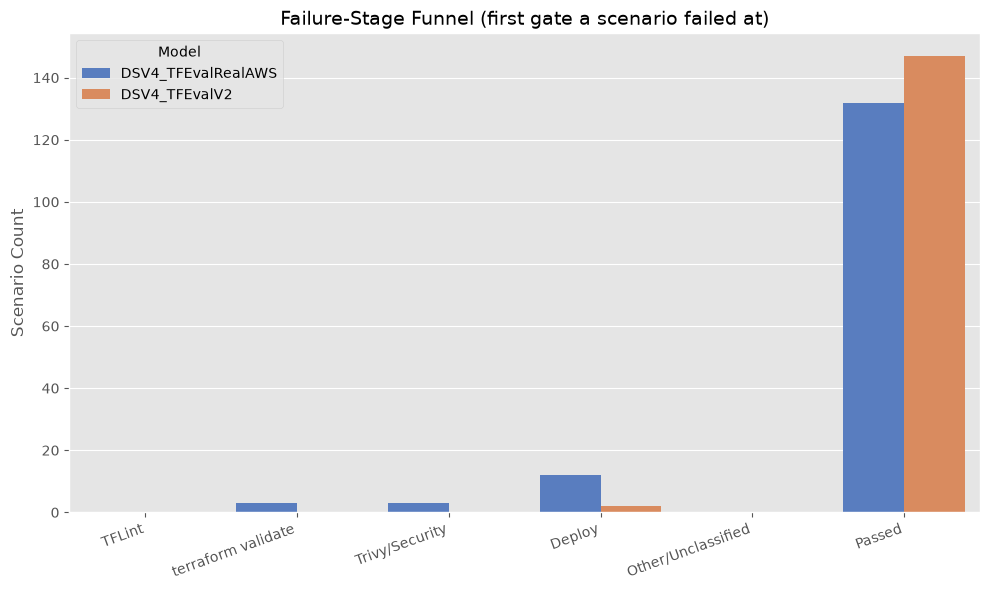

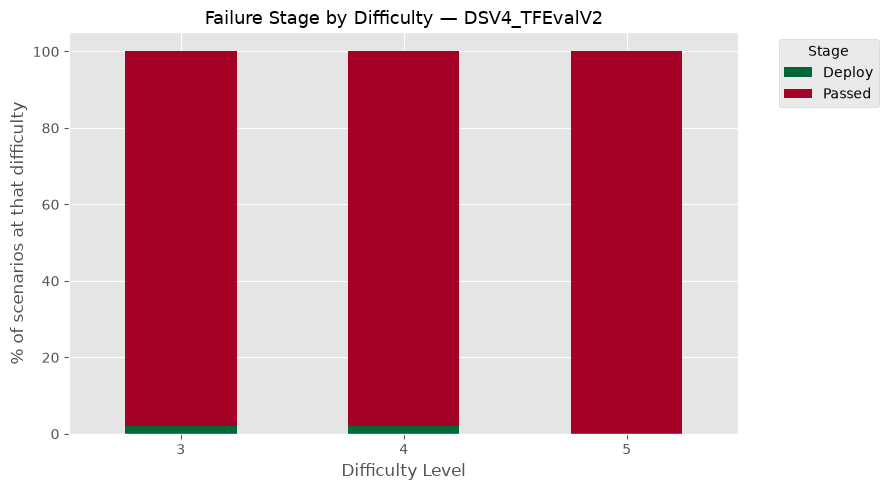

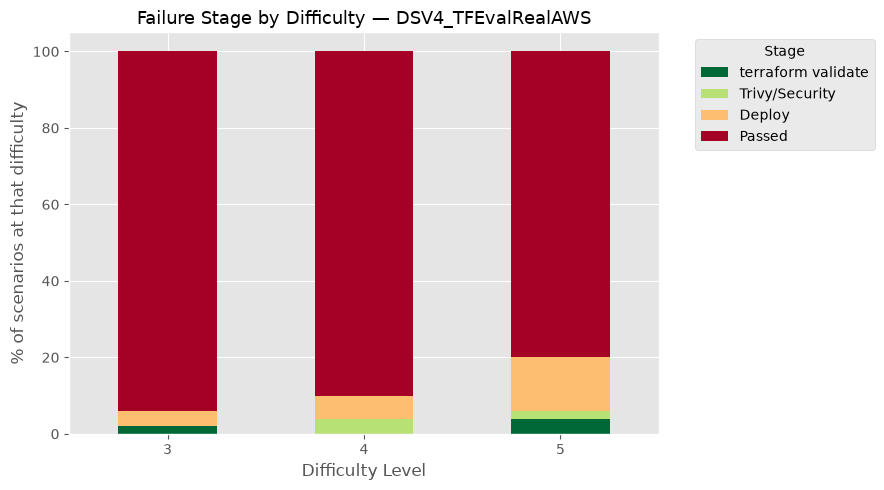

In [14]:
# ── 7. Failure-Stage Funnel ────────────────────────────────────────────────
# Where does a run actually die? The pipeline gates in a fixed order (static
# validation -> security scan -> deploy), so a scenario's `failure_stage` is
# the FIRST gate it failed at, not every gate it happened to fail. This is
# the single most useful triage view: it turns "final_validation_passed=False"
# into "which of the 4 stages actually stopped this run."

# NOTE: `all_yaml_errors`/`all_cfn_lint_errors` are the exporter's original CFN
# column names, reused as-is for the TF pipeline's tflint/terraform-validate
# cumulative error history rather than renamed -- same underlying schema.
STAGE_CONFIG = [
    {"key": "tflint",              "label": "TFLint",             "all_col": "all_yaml_errors",     "latest_col": "latest_error_tflint",             "passed_col": "val_stage_tflint_passed"},
    {"key": "terraform-validate",  "label": "terraform validate", "all_col": "all_cfn_lint_errors", "latest_col": "latest_error_terraform-validate", "passed_col": "val_stage_terraform-validate_passed"},
    {"key": "trivy",               "label": "Trivy/Security",     "all_col": "all_security_errors", "latest_col": "latest_error_trivy",              "passed_col": "val_stage_trivy_passed"},
]

# TF's merged frame carries the difficulty column as `difficulty`, not
# `difficulty_level` (CFN's name) -- normalize once so every cell below can
# use one consistent column name regardless of which benchmark this is.
for _df in merged_dataframes.values():
    if "difficulty_level" not in _df.columns and "difficulty" in _df.columns:
        _df["difficulty_level"] = _df["difficulty"]

def compute_failure_stage(row: pd.Series) -> str:
    """First gate (in pipeline order) that this scenario failed, or 'Passed'."""
    for stage in STAGE_CONFIG:
        col = stage["passed_col"]
        if col in row.index and row[col] is False:
            return stage["label"]
    if "deploy_passed" in row.index and row["deploy_passed"] is False:
        return "Deploy"
    if "final_validation_passed" in row.index and row["final_validation_passed"] is False:
        return "Other/Unclassified"
    return "Passed"

funnel_rows = []
for model_name, df in merged_dataframes.items():
    if "final_validation_passed" not in df.columns:
        continue
    df["failure_stage"] = df.apply(compute_failure_stage, axis=1)
    counts = df["failure_stage"].value_counts()
    for stage_label, cnt in counts.items():
        funnel_rows.append({"Model": model_name, "Stage": stage_label, "Count": cnt, "Pct": cnt / len(df) * 100})

if funnel_rows:
    funnel_df = pd.DataFrame(funnel_rows)
    stage_order = [s["label"] for s in STAGE_CONFIG] + ["Deploy", "Other/Unclassified", "Passed"]
    funnel_df["Stage"] = pd.Categorical(funnel_df["Stage"], categories=stage_order, ordered=True)
    funnel_df = funnel_df.sort_values(["Model", "Stage"])

    print("📊 Failure-stage funnel (first gate that stopped each scenario):")
    with pd.option_context('display.max_rows', None):
        display(funnel_df.pivot(index="Stage", columns="Model", values="Count").fillna(0).astype(int))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=funnel_df, x="Stage", y="Count", hue="Model", order=stage_order)
    plt.title("Failure-Stage Funnel (first gate a scenario failed at)", fontsize=14)
    plt.ylabel("Scenario Count")
    plt.xlabel("")
    plt.xticks(rotation=20, ha="right")
    plt.legend(title="Model")
    plt.tight_layout()
    plt.show()

    # Same funnel again, but by difficulty level, one small-multiple per model
    for model_name, df in merged_dataframes.items():
        if "difficulty_level" not in df.columns or "failure_stage" not in df.columns:
            continue
        cross = pd.crosstab(df["difficulty_level"], df["failure_stage"])
        cross = cross.reindex(columns=[s for s in stage_order if s in cross.columns])
        cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

        cross_pct.plot(kind="bar", stacked=True, figsize=(9, 5), colormap="RdYlGn_r")
        plt.title(f"Failure Stage by Difficulty — {model_name}", fontsize=13)
        plt.ylabel("% of scenarios at that difficulty")
        plt.xlabel("Difficulty Level")
        plt.xticks(rotation=0)
        plt.legend(title="Stage", bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()
else:
    print("⚠️ No models with 'final_validation_passed' / stage columns found.")


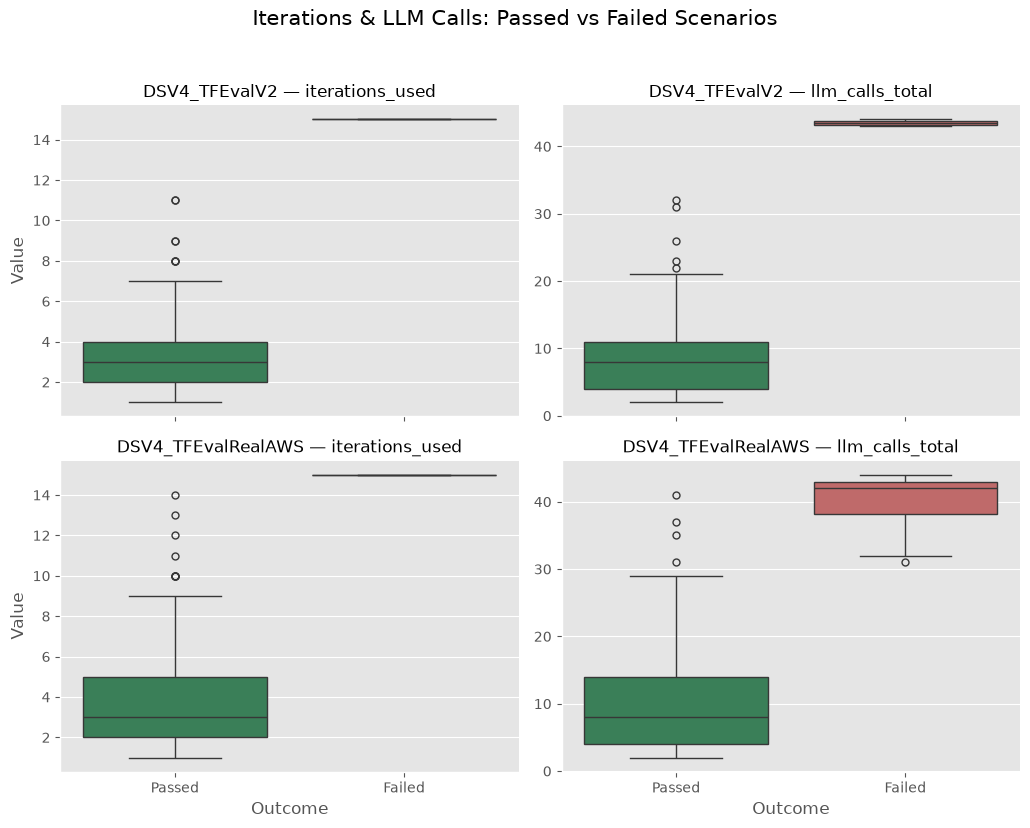

📊 Mean effort by outcome:


mean  median   max  count
Model              Metric          Outcome                            
DSV4_TFEvalRealAWS iterations_used Failed   15.00    15.0  15.0     18
                                   Passed    3.92     3.0  14.0    132
                   llm_calls_total Failed   40.06    42.0  44.0     18
                                   Passed   10.26     8.0  41.0    132
DSV4_TFEvalV2      iterations_used Failed   15.00    15.0  15.0      2
                                   Passed    3.50     3.0  11.0    147
                   llm_calls_total Failed   43.50    43.5  44.0      2
                                   Passed    8.76     8.0  32.0    147

  DSV4_TFEvalV2: 2/2 failed scenarios (100%) hit the observed max iteration count (15) before giving up -- the rest failed before exhausting their budget.
  DSV4_TFEvalRealAWS: 18/18 failed scenarios (100%) hit the observed max iteration count (15) before giving up -- the rest failed before exhausting their budget.


In [15]:
# ── 8. Effort vs Outcome (iterations & LLM calls) ──────────────────────────
# Do failures happen because the agent gave up fast, or because it burned
# its whole iteration budget and still couldn't converge? Both are "failure"
# but they call for different fixes (better first-shot generation vs. a
# larger iteration budget / a remediator that's stuck in a loop).

effort_cols = [c for c in ["iterations_used", "llm_calls_total", "duration_seconds"] if True]

effort_rows = []
for model_name, df in merged_dataframes.items():
    if "final_validation_passed" not in df.columns or "iterations_used" not in df.columns:
        continue
    outcome = df["final_validation_passed"].map({True: "Passed", False: "Failed"})
    for col in ["iterations_used", "llm_calls_total"]:
        if col not in df.columns:
            continue
        tmp = pd.DataFrame({"Model": model_name, "Outcome": outcome, "Metric": col, "Value": df[col]})
        effort_rows.append(tmp)

if effort_rows:
    effort_df = pd.concat(effort_rows, ignore_index=True).dropna(subset=["Value"])

    g = sns.catplot(
        data=effort_df, kind="box",
        x="Outcome", y="Value", hue="Outcome", col="Metric", row="Model",
        palette={"Passed": "seagreen", "Failed": "indianred"},
        height=4, aspect=1.3, sharey=False, legend=False,
    )
    g.set_titles("{row_name} — {col_name}")
    g.fig.suptitle("Iterations & LLM Calls: Passed vs Failed Scenarios", fontsize=15, y=1.03)
    plt.tight_layout()
    plt.show()

    print("📊 Mean effort by outcome:")
    summary = effort_df.groupby(["Model", "Metric", "Outcome"])["Value"].agg(["mean", "median", "max", "count"]).round(2)
    display(summary)

    # Did failed scenarios tend to exhaust the iteration budget?
    for model_name, df in merged_dataframes.items():
        if "iterations_used" not in df.columns or "final_validation_passed" not in df.columns:
            continue
        max_iter = df["iterations_used"].max()
        exhausted = df[(df["final_validation_passed"] == False) & (df["iterations_used"] >= max_iter)]
        n_failed = (df["final_validation_passed"] == False).sum()
        if n_failed:
            print(f"  {model_name}: {len(exhausted)}/{n_failed} failed scenarios "
                  f"({len(exhausted)/n_failed:.0%}) hit the observed max iteration count ({max_iter:.0f}) "
                  f"before giving up -- the rest failed before exhausting their budget.")
else:
    print("⚠️ No models with iteration/effort columns found.")


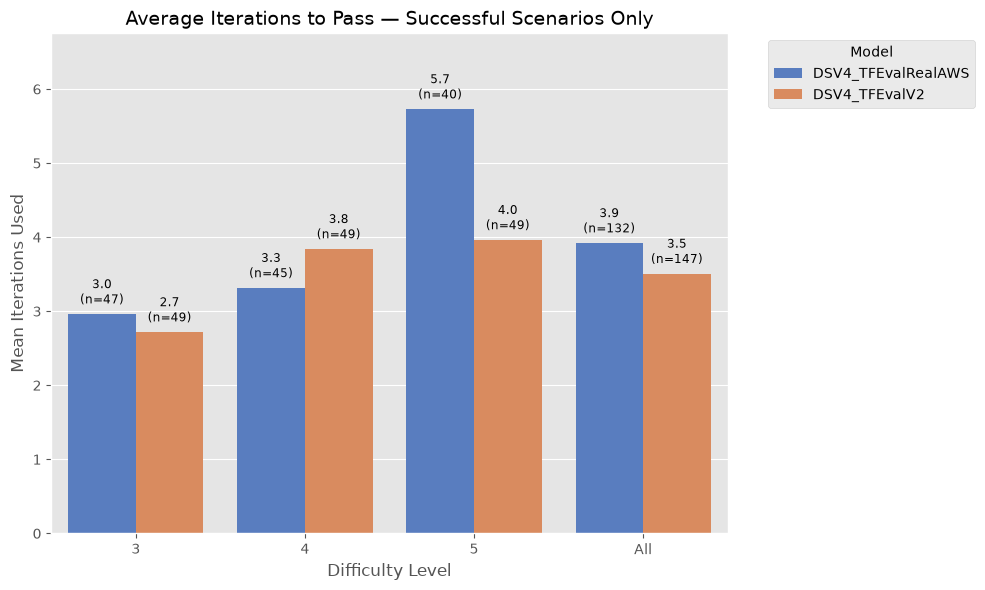

📊 Average iterations to pass, by difficulty (successful scenarios only):


,Model,Difficulty Level,N Passed,Mean Iterations,Median Iterations
0,DSV4_TFEvalRealAWS,3,47,2.96,2.0
1,DSV4_TFEvalV2,3,49,2.71,2.0
2,DSV4_TFEvalRealAWS,4,45,3.31,3.0
3,DSV4_TFEvalV2,4,49,3.84,3.0
4,DSV4_TFEvalRealAWS,5,40,5.72,5.0
5,DSV4_TFEvalV2,5,49,3.96,4.0
6,DSV4_TFEvalRealAWS,All,132,3.92,3.0
7,DSV4_TFEvalV2,All,147,3.50,3.0


In [16]:
# ── 8b. Average Iterations to Pass (Successful Scenarios Only) ────────────
# The Effort-vs-Outcome cell above already shows iterations split by
# Passed/Failed -- this drills into just the Passed side by difficulty, to
# answer a narrower, practical question: "for a scenario this hard, how many
# repair iterations should we budget for before the agent typically
# converges?" Failed scenarios are excluded entirely here since their
# iteration count just reflects the max-iteration cap, not genuine effort-
# to-converge (see the "hit the observed max iteration budget" finding
# above).
avg_iter_rows = []
for model_name, df in merged_dataframes.items():
    if "final_validation_passed" not in df.columns or "iterations_used" not in df.columns:
        continue
    diff_col = "difficulty_level" if "difficulty_level" in df.columns else "difficulty"
    if diff_col not in df.columns:
        continue
    passed = df[df["final_validation_passed"] == True]
    grouped = passed.groupby(diff_col)["iterations_used"].agg(["mean", "median", "count"])
    for diff, row in grouped.iterrows():
        avg_iter_rows.append({
            "Model": model_name, "Difficulty Level": diff,
            "Mean Iterations": row["mean"], "Median Iterations": row["median"], "N Passed": int(row["count"]),
        })
    if len(passed):
        avg_iter_rows.append({
            "Model": model_name, "Difficulty Level": "All",
            "Mean Iterations": passed["iterations_used"].mean(),
            "Median Iterations": passed["iterations_used"].median(), "N Passed": len(passed),
        })

if avg_iter_rows:
    avg_iter_df = pd.DataFrame(avg_iter_rows)
    order = sorted([d for d in avg_iter_df["Difficulty Level"].unique() if d != "All"]) + ["All"]
    avg_iter_df["Difficulty Level"] = pd.Categorical(avg_iter_df["Difficulty Level"], categories=order, ordered=True)
    avg_iter_df = avg_iter_df.sort_values(["Difficulty Level", "Model"])

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=avg_iter_df, x="Difficulty Level", y="Mean Iterations", hue="Model", order=order)
    plt.title("Average Iterations to Pass — Successful Scenarios Only", fontsize=14)
    plt.ylim(0, avg_iter_df["Mean Iterations"].max() * 1.18)
    plt.ylabel("Mean Iterations Used")
    plt.xlabel("Difficulty Level")
    plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")

    for i, container in enumerate(ax.containers):
        model_name = ax.get_legend().get_texts()[i].get_text()
        for j, p in enumerate(container):
            height = p.get_height()
            if pd.isna(height) or (height == 0 and p.get_y() == 0):
                continue
            diff_level = ax.get_xticklabels()[j].get_text()
            row = avg_iter_df[(avg_iter_df["Model"] == model_name) & (avg_iter_df["Difficulty Level"].astype(str) == diff_level)]
            if not row.empty:
                n = row["N Passed"].values[0]
                ax.annotate(f"{height:.1f}\n(n={n})", (p.get_x() + p.get_width() / 2., height),
                            ha="center", va="bottom", xytext=(0, 5), textcoords="offset points", fontsize=8.5)

    plt.tight_layout()
    plt.show()

    print("📊 Average iterations to pass, by difficulty (successful scenarios only):")
    display(avg_iter_df[["Model", "Difficulty Level", "N Passed", "Mean Iterations", "Median Iterations"]]
            .round(2).reset_index(drop=True))
else:
    print("⚠️ No models with iterations_used/final_validation_passed/difficulty columns found.")


📊 Token & duration totals per model:


,total_tokens,mean_tokens,total_input_tokens,total_output_tokens,mean_duration_s,total_est_cost_usd
Model,,,,,,
DSV4_TFEvalRealAWS,47528503.0,316856.69,0.0,0.0,990.64,0.0
DSV4_TFEvalV2,17130562.0,114970.21,0.0,0.0,711.53,0.0


  ℹ️ INPUT_COST_PER_MTOK / OUTPUT_COST_PER_MTOK are both 0 -- set them above to see $ estimates instead of just token counts.


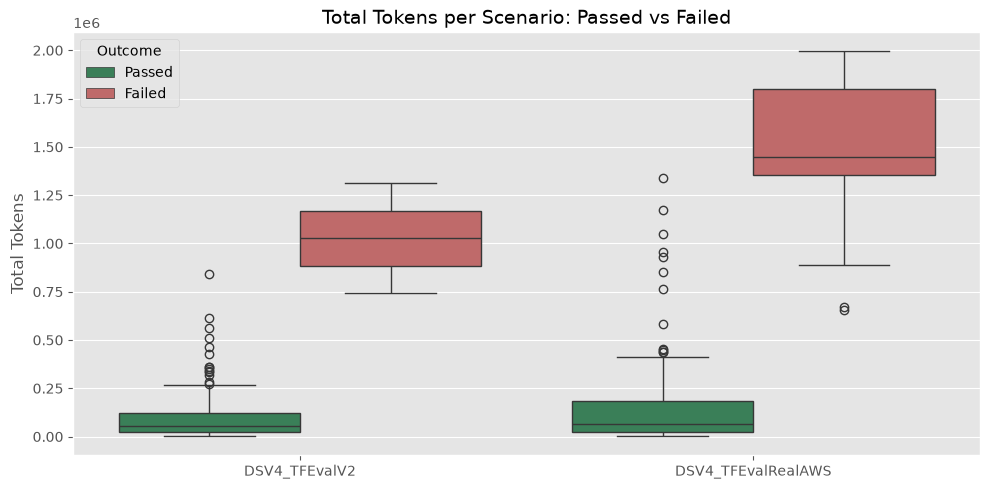

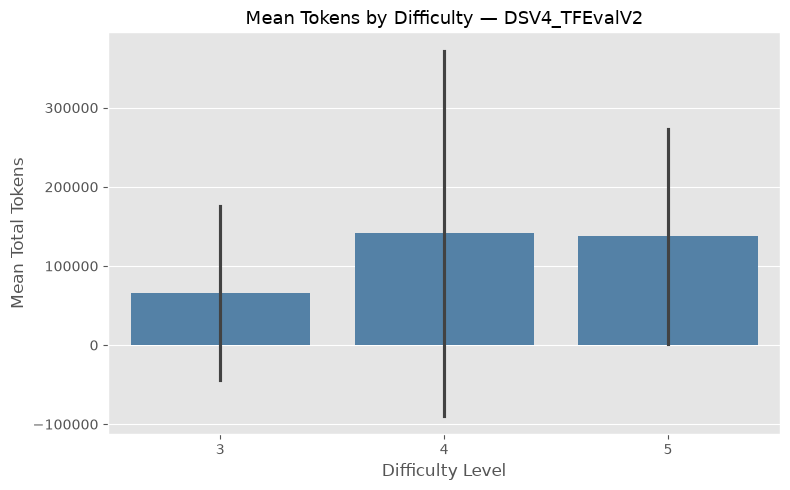

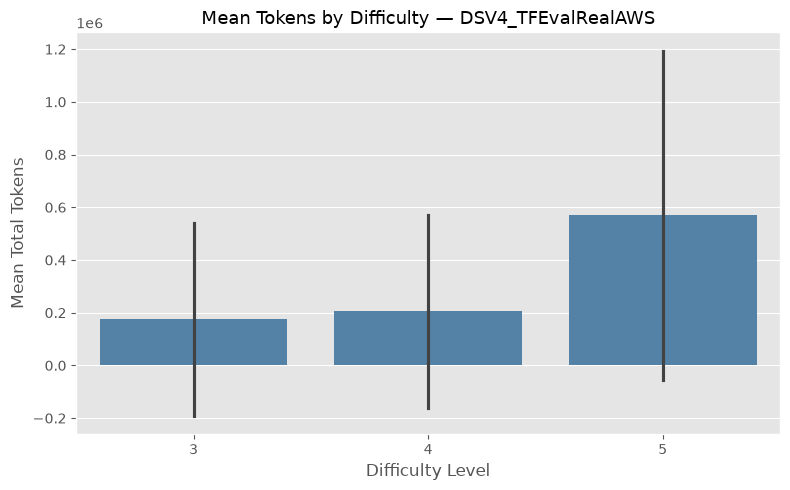

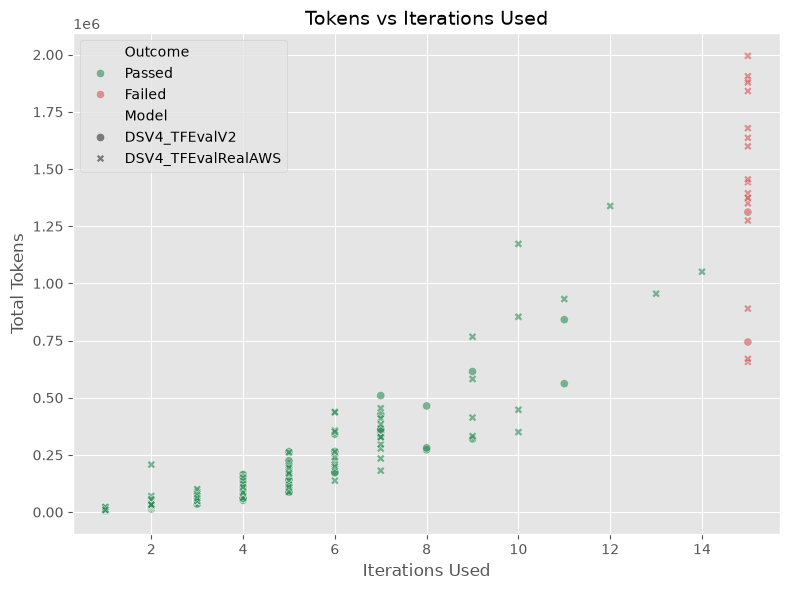

In [17]:
# ── 9. Token Cost & Duration Analysis ──────────────────────────────────────
# Set these to your actual OpenRouter per-million-token rate to see $ cost
# estimates; leave at 0 to only see raw token counts. (deepseek/deepseek-v4-flash
# pricing on OpenRouter changes over time -- check openrouter.ai/models before
# trusting a $ figure pulled from an old note.)
INPUT_COST_PER_MTOK = 0.0    # USD per 1,000,000 input/prompt tokens
OUTPUT_COST_PER_MTOK = 0.0   # USD per 1,000,000 output/completion tokens

token_cols_present = {c for c in ["token_input_tokens", "token_output_tokens", "token_all_tokens"]
                       if any(c in df.columns for df in merged_dataframes.values())}

if token_cols_present:
    cost_rows = []
    for model_name, df in merged_dataframes.items():
        if "token_all_tokens" not in df.columns:
            continue
        d = df.copy()
        d["est_cost_usd"] = (
            d.get("token_input_tokens", 0).fillna(0) / 1_000_000 * INPUT_COST_PER_MTOK
            + d.get("token_output_tokens", 0).fillna(0) / 1_000_000 * OUTPUT_COST_PER_MTOK
        )
        d["Model"] = model_name
        d["Outcome"] = d["final_validation_passed"].map({True: "Passed", False: "Failed"}) \
            if "final_validation_passed" in d.columns else "Unknown"
        cost_rows.append(d[["Model", "Outcome", "token_input_tokens", "token_output_tokens",
                             "token_all_tokens", "iterations_used", "duration_seconds", "est_cost_usd"]])

    cost_df = pd.concat(cost_rows, ignore_index=True)

    print("📊 Token & duration totals per model:")
    totals = cost_df.groupby("Model").agg(
        total_tokens=("token_all_tokens", "sum"),
        mean_tokens=("token_all_tokens", "mean"),
        total_input_tokens=("token_input_tokens", "sum"),
        total_output_tokens=("token_output_tokens", "sum"),
        mean_duration_s=("duration_seconds", "mean"),
        total_est_cost_usd=("est_cost_usd", "sum"),
    ).round(2)
    display(totals)

    if (INPUT_COST_PER_MTOK == 0) and (OUTPUT_COST_PER_MTOK == 0):
        print("  ℹ️ INPUT_COST_PER_MTOK / OUTPUT_COST_PER_MTOK are both 0 -- "
              "set them above to see $ estimates instead of just token counts.")

    # Tokens by outcome (passed vs failed) -- are failures cheap fast-fails or expensive dead ends?
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=cost_df, x="Model", y="token_all_tokens", hue="Outcome",
                palette={"Passed": "seagreen", "Failed": "indianred", "Unknown": "gray"})
    plt.title("Total Tokens per Scenario: Passed vs Failed", fontsize=14)
    plt.ylabel("Total Tokens")
    plt.xlabel("")
    plt.tight_layout()
    plt.show()

    # Tokens by difficulty
    for model_name, df in merged_dataframes.items():
        if "difficulty_level" not in df.columns or "token_all_tokens" not in df.columns:
            continue
        plt.figure(figsize=(8, 5))
        sns.barplot(data=df, x="difficulty_level", y="token_all_tokens", errorbar="sd", color="steelblue")
        plt.title(f"Mean Tokens by Difficulty — {model_name}", fontsize=13)
        plt.xlabel("Difficulty Level")
        plt.ylabel("Mean Total Tokens")
        plt.tight_layout()
        plt.show()

    # Cost efficiency: $/passed scenario vs $/failed scenario (only meaningful once cost > 0)
    if cost_df["est_cost_usd"].sum() > 0:
        eff = cost_df.groupby(["Model", "Outcome"])["est_cost_usd"].agg(["sum", "mean", "count"]).round(4)
        print("\n📊 Cost efficiency (est. $ spent, passed vs failed):")
        display(eff)

    # Tokens vs iterations -- confirms cost scales with remediation-loop length
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=cost_df, x="iterations_used", y="token_all_tokens", hue="Outcome",
                     style="Model", alpha=0.6,
                     palette={"Passed": "seagreen", "Failed": "indianred", "Unknown": "gray"})
    plt.title("Tokens vs Iterations Used", fontsize=14)
    plt.xlabel("Iterations Used")
    plt.ylabel("Total Tokens")
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No token columns found in any model's dataframe.")


## Common Failures / Failure Patterns

What errors come up most often per validation stage — across every scenario a code was ever seen in, versus only the scenarios where that code never got resolved? Plus deploy-time failure signatures and how error codes cluster by difficulty.

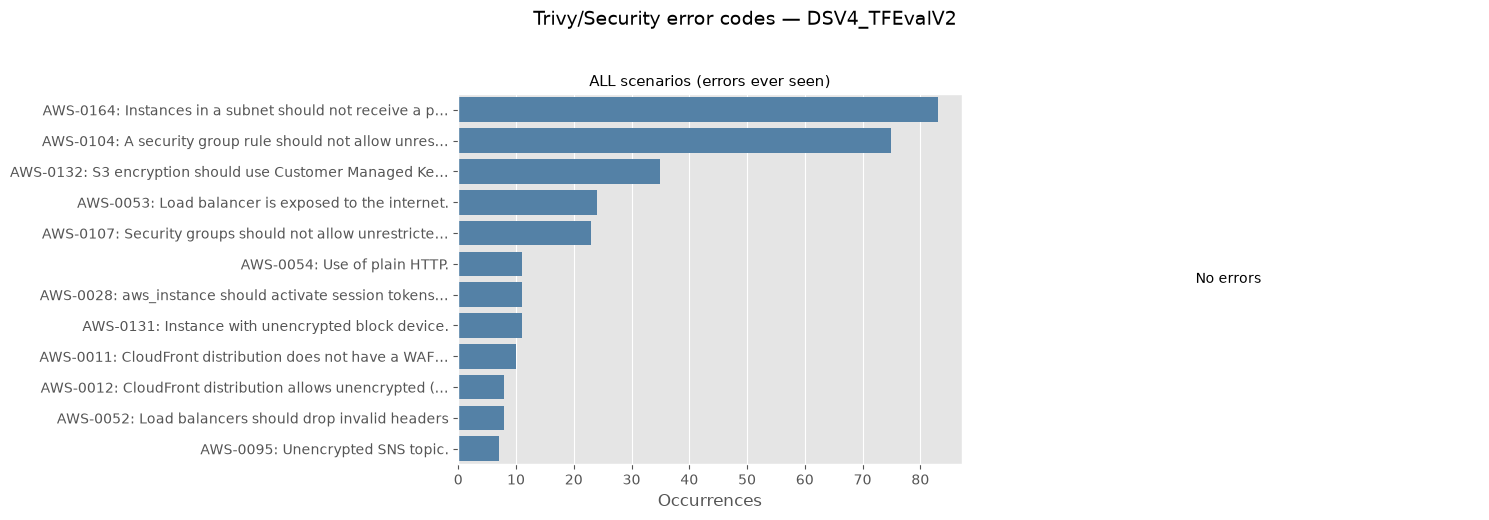

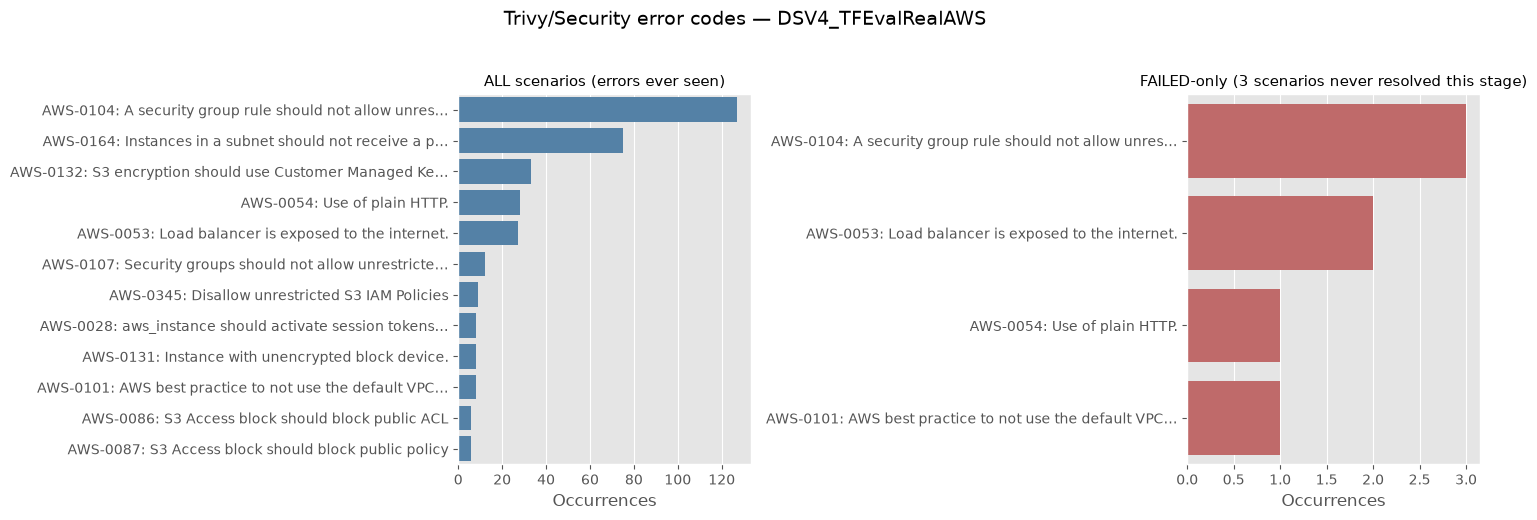

In [18]:
# ── 10. Common Failure Patterns per Validation Stage ───────────────────────
# Two different questions, both worth asking:
#   "ALL scenarios"    -- every error code that ever appeared during a run's
#                          remediation loop (from the cumulative all_*_errors
#                          columns), regardless of whether it ended up fixed.
#                          This is "what trips the LLM up in general."
#   "FAILED-only"       -- the error code(s) still present in the FINAL
#                          iteration of a scenario whose stage never passed
#                          (latest_error_* filtered to val_stage_*_passed ==
#                          False). This is "what actually beat the agent."
# A code that's common in the ALL view but rare in the FAILED view is a code
# the remediator reliably fixes; a code common in BOTH is a recurring blind
# spot worth a benchmark- or agent-level fix.
#
# A bare code (e.g. "E3004") on its own isn't very readable -- every plot in
# this section labels the bar with the code's own most-common human-readable
# message too ("E3004: Circular Dependencies for resource ..."), truncated to
# stay compact. `CODE_MESSAGES` is a shared, growing code->message lookup that
# every later cell in this section (heatmap, memory/remediation) reuses too,
# since it's the same validator vocabulary regardless of which text it was
# pulled from (the CSV's cumulative error columns, a per-iteration JSON error
# list, or a remediator's own free-text citation of a code).

import re
from collections import defaultdict

CODE_RE = re.compile(r"\[([A-Za-z0-9_.\-]{1,20})\]")
GOOD_CODE_RE = re.compile(r"^(?:[EWI]\d{3,4}|AWS-\d{3,4}|[a-z][a-z_-]{2,19}|None)$")
_LINE_PREFIX_RE = re.compile(r"^\s*line\s+\d+(?:\s*,\s*column\s+\d+)?\s*:?\s*", re.I)
_RESOURCE_ONLY_RE = re.compile(r"^\s*Resource:\s*\S+\s*$", re.I)
_LINE_ONLY_RE = re.compile(r"^\s*line\s+\d+\s*$", re.I)
_SEVERITY_RE = re.compile(r"^\s*(CRITICAL|HIGH|MEDIUM|LOW)\s*:\s*", re.I)

CODE_MESSAGES = defaultdict(Counter)  # code -> Counter(message -> occurrences)

def extract_error_entries(text) -> list:
    """Pull (code, message) pairs out of a pipe-concatenated validator error
    string. Each code's message is its own first meaningful segment -- the
    surrounding `line N` / `Resource: X` / trailing-rationale noise (and, for
    Trivy, the severity word and the "— extra detail" half) is stripped out,
    since that's not what makes one error distinguishable from another."""
    if not isinstance(text, str) or not text.strip():
        return []
    matches = list(CODE_RE.finditer(text))
    entries = []
    for i, m in enumerate(matches):
        code = m.group(1)
        if not GOOD_CODE_RE.match(code):
            continue
        start = m.end()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        segs = [s.strip() for s in text[start:end].split("|") if s.strip()]
        msg = ""
        for seg in segs:
            if _LINE_ONLY_RE.match(seg) or _RESOURCE_ONLY_RE.match(seg):
                continue
            seg = _SEVERITY_RE.sub("", _LINE_PREFIX_RE.sub("", seg)).strip()
            if " — " in seg:
                seg = seg.split(" — ", 1)[0].strip()
            if seg:
                msg = seg
                break
        entries.append((code, msg))
    return entries

def extract_error_codes(text) -> list:
    return [c for c, _ in extract_error_entries(text)]

def record_messages(entries) -> None:
    for code, msg in entries:
        if msg:
            CODE_MESSAGES[code][msg] += 1

def truncate_msg(msg: str, width: int = 45) -> str:
    msg = re.sub(r"\s+", " ", msg).strip()
    return msg if len(msg) <= width else msg[: width - 1].rstrip() + "…"

def describe_code(code: str, width: int = 45) -> str:
    """'CODE' -> 'CODE: most common message for this code, truncated'."""
    msgs = CODE_MESSAGES.get(code)
    if not msgs:
        return code
    best_msg, _ = msgs.most_common(1)[0]
    return f"{code}: {truncate_msg(best_msg, width)}"

def top_codes_from_column(df: pd.DataFrame, col: str, mask: pd.Series = None) -> Counter:
    counter = Counter()
    series = df[col] if mask is None else df.loc[mask, col]
    for txt in series.dropna():
        entries = extract_error_entries(txt)
        counter.update(c for c, _ in entries)
        record_messages(entries)
    return counter

for stage in STAGE_CONFIG:
    for model_name, df in merged_dataframes.items():
        if stage["all_col"] not in df.columns or stage["passed_col"] not in df.columns:
            continue

        all_counter = top_codes_from_column(df, stage["all_col"])
        failed_mask = df[stage["passed_col"]] == False
        failed_counter = top_codes_from_column(df, stage["latest_col"], mask=failed_mask)

        if not all_counter and not failed_counter:
            continue

        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        for ax, counter, title, color in [
            (axes[0], all_counter, f"ALL scenarios (errors ever seen)", "steelblue"),
            (axes[1], failed_counter, f"FAILED-only ({int(failed_mask.sum())} scenarios never resolved this stage)", "indianred"),
        ]:
            top = pd.DataFrame(counter.most_common(12), columns=["Code", "Count"])
            if top.empty:
                ax.text(0.5, 0.5, "No errors", ha="center", va="center")
                ax.set_axis_off()
                continue
            top["Label"] = top["Code"].apply(describe_code)
            sns.barplot(data=top, y="Label", x="Count", color=color, ax=ax)
            ax.set_title(title, fontsize=11)
            ax.set_xlabel("Occurrences")
            ax.set_ylabel("")
        fig.suptitle(f"{stage['label']} error codes — {model_name}", fontsize=14, y=1.03)
        plt.tight_layout()
        plt.show()


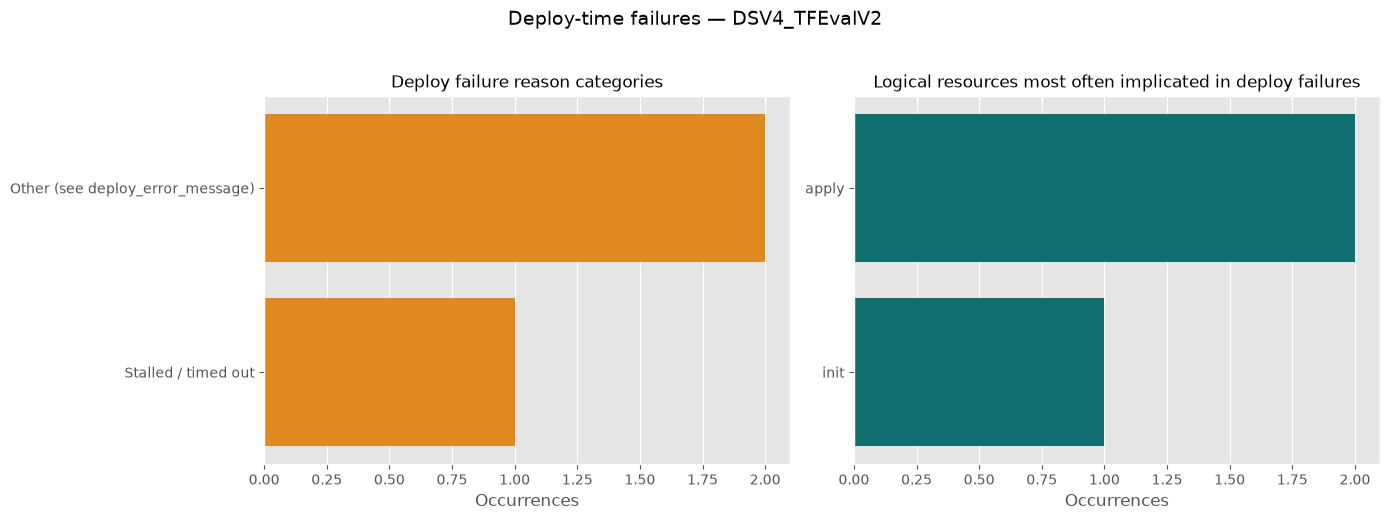

  DSV4_TFEvalV2: 2 scenario(s) failed to deploy; 0 of the reported reasons are the generic CloudFormation 'call DescribeEvents' message, which needs the AWS console/CLI to see the real underlying error.


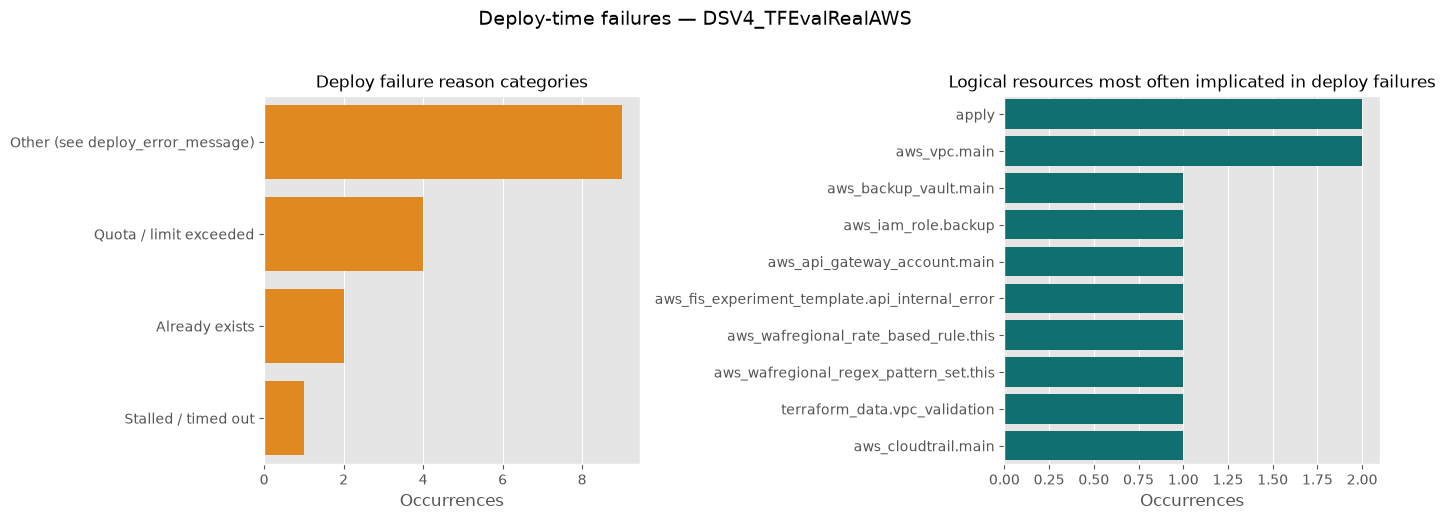

  DSV4_TFEvalRealAWS: 12 scenario(s) failed to deploy; 0 of the reported reasons are the generic CloudFormation 'call DescribeEvents' message, which needs the AWS console/CLI to see the real underlying error.


In [19]:
# ── 11. Deploy-Time Failure Reasons ─────────────────────────────────────────
# Static validation and Trivy both give structured, code-carrying errors;
# deploy failures don't -- CloudFormation returns free-text status reasons.
# Bucket them into recognizable signature classes so "what's actually
# killing deploys" is readable at a glance instead of 150 unique strings.

import json as _json

DEPLOY_SIGNATURES = [
    ("Resource creation cancelled (rollback)", re.compile(r"creation cancelled", re.I)),
    ("Stalled / timed out", re.compile(r"stalled|timed?\s*out|>\s*\d+s\b", re.I)),
    ("Already exists", re.compile(r"already\s*exists", re.I)),
    ("Access denied / not authorized", re.compile(r"access\s*denied|not\s*authorized|forbidden", re.I)),
    ("Invalid parameter / value", re.compile(r"invalid\s*(parameter|value|request|instanceid|json)", re.I)),
    ("Quota / limit exceeded", re.compile(r"limit\s*exceeded|quota", re.I)),
    ("Validation failed (generic, needs DescribeEvents)", re.compile(r"validation\s*failed", re.I)),
]
STACK_NAME_RE = re.compile(r"^iac-god-eval-[0-9a-f]{6,}$")

def parse_deploy_failed_resources(cell):
    if not isinstance(cell, str) or not cell.strip():
        return []
    try:
        items = _json.loads(cell)
    except (ValueError, TypeError):
        return []
    out = []
    for it in items:
        if isinstance(it, dict):
            out.append((it.get("logical_name"), it.get("status_reason")))
    return out

def classify_deploy_reason(text) -> str:
    if not isinstance(text, str):
        return "Unknown"
    for label, pat in DEPLOY_SIGNATURES:
        if pat.search(text):
            return label
    return "Other (see deploy_error_message)"

for model_name, df in merged_dataframes.items():
    if "deploy_failed_resources" not in df.columns:
        continue

    reason_counter = Counter()
    resource_counter = Counter()
    for cell in df["deploy_failed_resources"].dropna():
        for name, reason in parse_deploy_failed_resources(cell):
            reason_counter[classify_deploy_reason(reason)] += 1
            if name and not STACK_NAME_RE.match(name):
                resource_counter[name] += 1

    if not reason_counter:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    top_reasons = pd.DataFrame(reason_counter.most_common(10), columns=["Reason", "Count"])
    sns.barplot(data=top_reasons, y="Reason", x="Count", color="darkorange", ax=axes[0])
    axes[0].set_title("Deploy failure reason categories", fontsize=12)
    axes[0].set_xlabel("Occurrences")
    axes[0].set_ylabel("")

    top_res = pd.DataFrame(resource_counter.most_common(10), columns=["Logical Resource", "Count"])
    if not top_res.empty:
        sns.barplot(data=top_res, y="Logical Resource", x="Count", color="teal", ax=axes[1])
        axes[1].set_title("Logical resources most often implicated in deploy failures", fontsize=12)
        axes[1].set_xlabel("Occurrences")
        axes[1].set_ylabel("")
    else:
        axes[1].text(0.5, 0.5, "No per-resource detail\n(stack-level failure only)", ha="center", va="center")
        axes[1].set_axis_off()

    fig.suptitle(f"Deploy-time failures — {model_name}", fontsize=14, y=1.03)
    plt.tight_layout()
    plt.show()

    n_deploy_fail = (df["deploy_passed"] == False).sum() if "deploy_passed" in df.columns else None
    if n_deploy_fail:
        print(f"  {model_name}: {n_deploy_fail} scenario(s) failed to deploy; "
              f"{reason_counter.get('Validation failed (generic, needs DescribeEvents)', 0)} of the reported "
              f"reasons are the generic CloudFormation 'call DescribeEvents' message, which needs the AWS "
              f"console/CLI to see the real underlying error.")


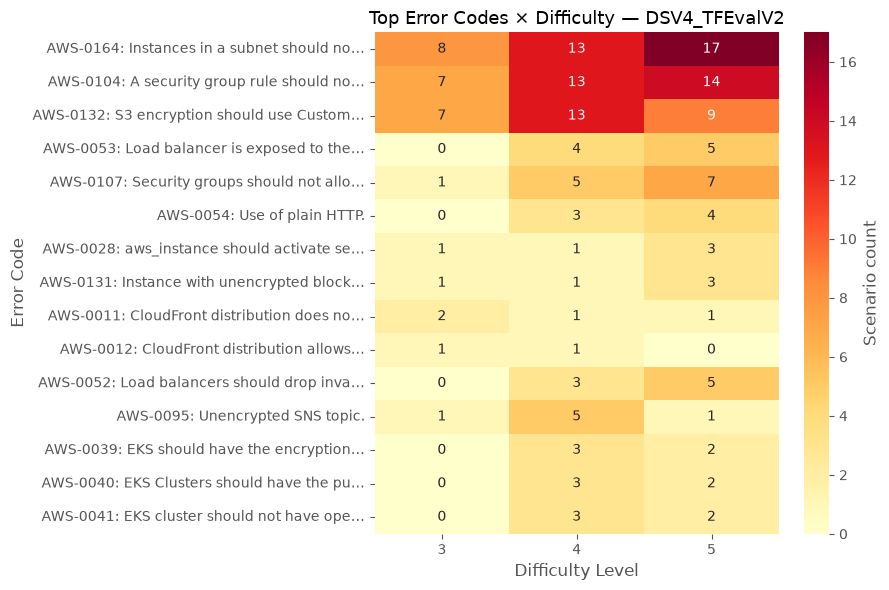

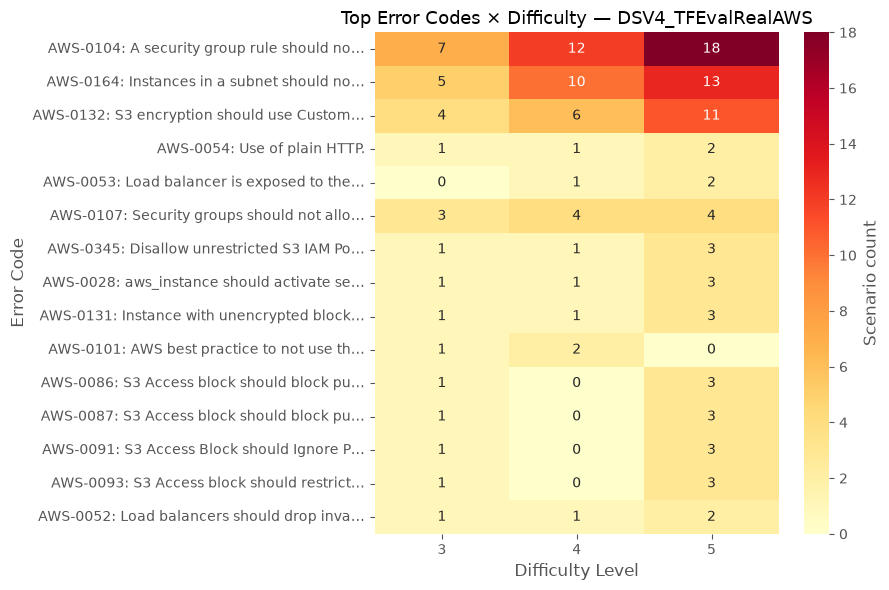

In [20]:
# ── 12. Error Codes × Difficulty Heatmap ────────────────────────────────────
# Which validation-stage errors cluster at which difficulty level? Combines
# every stage's cumulative errors (ALL scenarios) into one view per model so
# the top ~15 codes overall are cross-tabbed against difficulty.

for model_name, df in merged_dataframes.items():
    if "difficulty_level" not in df.columns:
        continue

    combined_counter = Counter()
    for stage in STAGE_CONFIG:
        if stage["all_col"] in df.columns:
            combined_counter.update(top_codes_from_column(df, stage["all_col"]))
    if not combined_counter:
        continue

    top_codes = [c for c, _ in combined_counter.most_common(15)]

    heat_rows = []
    for _, row in df.iterrows():
        diff = row.get("difficulty_level")
        if pd.isna(diff):
            continue
        codes_here = set()
        for stage in STAGE_CONFIG:
            codes_here.update(extract_error_codes(row.get(stage["all_col"])))
        for c in codes_here & set(top_codes):
            heat_rows.append({"Difficulty": diff, "Code": c})

    if not heat_rows:
        continue

    heat_df = pd.DataFrame(heat_rows)
    pivot = pd.crosstab(heat_df["Code"], heat_df["Difficulty"]).reindex(top_codes)
    pivot.index = [describe_code(c, width=32) for c in pivot.index]

    plt.figure(figsize=(9, 6))
    sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrRd", cbar_kws={"label": "Scenario count"})
    plt.title(f"Top Error Codes × Difficulty — {model_name}", fontsize=13)
    plt.xlabel("Difficulty Level")
    plt.ylabel("Error Code")
    plt.tight_layout()
    plt.show()


## Memory & Remediation Analysis (optional — requires local IaCGOD run logs)

Everything above comes from the aggregated result CSV. This section reaches into each run's full per-iteration transcript on disk (`../IaCGOD/runs/<...>/<run_id>/`) to look at the agent's actual remediation reasoning: does the same error recur across iterations, how many fix objectives does the remediator issue per turn, and which error codes/root-cause themes does its reasoning cite — split by whether the run ultimately passed. If the sibling `IaCGOD` checkout (and its `runs/` directory) isn't present, this section prints a warning and produces nothing rather than failing.

In [21]:
# ── 13. Locate Run Logs (setup) ─────────────────────────────────────────────
# Everything above comes from the aggregated result CSV. But each run also
# has a full per-iteration transcript on disk under ../IaCGOD/runs/<...>/<run_id>/
# (remediator_history.txt, iteration_NNN.json, final_report.json, ...) --
# that's the only place the agent's actual root-cause reasoning and fix
# objectives live, so it's the source for the "memory analysis" below.
#
# Run collections aren't always grouped under a folder matching the result
# CSV's own filename (e.g. TFEvalV2's rows live under the older
# `TFEval_DeepseekV4Flash_security_runs/` collection folder) -- so instead of
# guessing a path from the result filename, this indexes every run_id found
# anywhere under RUNS_ROOT (one or two directory levels deep) and looks runs
# up by their globally-unique run_id. This is optional: if RUNS_ROOT doesn't
# exist (e.g. the sibling IaCGOD checkout isn't present), everything in this
# section degrades gracefully to "skipped."

import re
import json as _json
from pathlib import Path

RUNS_ROOT = Path("../IaCGOD/runs")
_RUN_ID_RE = re.compile(r"^\d{8}_\d{6}_[0-9a-f]{6,}$")

def build_run_index(runs_root: Path) -> dict:
    idx = {}
    if not runs_root.exists():
        return idx
    for entry in runs_root.iterdir():
        if not entry.is_dir():
            continue
        if _RUN_ID_RE.match(entry.name):
            idx[entry.name] = entry
            continue
        try:
            for sub in entry.iterdir():
                if sub.is_dir() and _RUN_ID_RE.match(sub.name):
                    idx[sub.name] = sub
        except (PermissionError, OSError):
            continue
    return idx

RUN_INDEX = build_run_index(RUNS_ROOT)
print(f"📁 Indexed {len(RUN_INDEX)} run directories under {RUNS_ROOT.resolve()}")

RUN_COVERAGE = {}
for model_name, df in merged_dataframes.items():
    if "run_id" not in df.columns:
        continue
    located = df["run_id"].isin(RUN_INDEX.keys())
    RUN_COVERAGE[model_name] = located
    print(f"  {model_name}: {located.sum()}/{len(df)} scenarios have a locatable run log "
          f"({located.sum()/len(df):.0%}).")

if not RUN_INDEX:
    print("⚠️ RUNS_ROOT not found or empty -- skip the rest of this section "
          "(memory/remediation analysis needs the sibling IaCGOD run logs on disk).")


📁 Indexed 2584 run directories under /Users/iksena/Documents/research/IaCGOD/runs
  DSV4_TFEvalV2: 149/149 scenarios have a locatable run log (100%).
  DSV4_TFEvalRealAWS: 150/150 scenarios have a locatable run log (100%).



DSV4_TFEvalV2  (analyzed 149 run logs)
  1 run(s) had an error code disappear then reappear in a later iteration.
  0 run(s) had an error code present in EVERY iteration (never cleared).
  Most-recurring codes: [('AWS-0054', 1)]
  Avg fix-objectives issued per remediation turn: 3.5 (396 remediation turns total across these runs).



DSV4_TFEvalRealAWS  (analyzed 150 run logs)
  5 run(s) had an error code disappear then reappear in a later iteration.
  0 run(s) had an error code present in EVERY iteration (never cleared).
  Most-recurring codes: [('AWS-0132', 2), ('AWS-0101', 2), ('AWS-0040', 1)]
  Avg fix-objectives issued per remediation turn: 2.9 (637 remediation turns total across these runs).


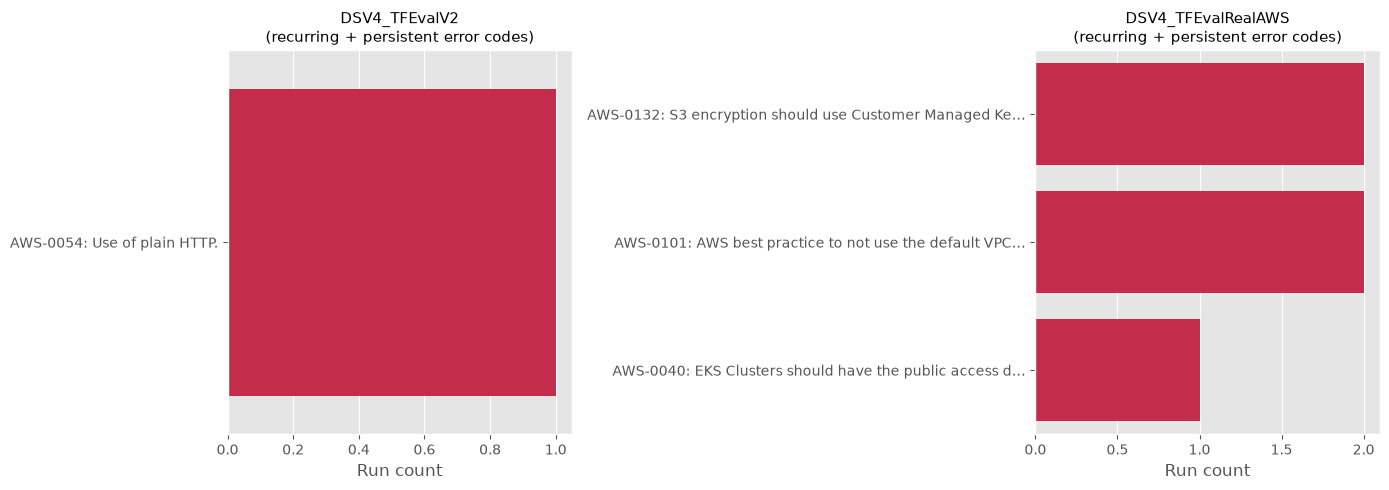

In [22]:
# ── 14. Remediation-Loop Memory: Recurring & Persistent Errors ─────────────
# Per-iteration validation_results in iteration_NNN.json is strictly richer
# than the CSV's "latest"/"cumulative" snapshot -- it lets us ask a genuinely
# different question: does the SAME error code go away and then come BACK in
# a later iteration (the remediator "fixed" it but a later edit reintroduced
# it), or does it sit there UNCHANGED across every iteration the run had
# (the remediator never manages to clear it, but the run ends -- passes or
# not -- before that's the sole blocker)? Both are signs of a remediation
# loop that isn't converging cleanly, as distinct from "took a few tries but
# got there."
FIX_OBJ_RE = re.compile(r"^\s*\d+\.\s+\*\*", re.MULTILINE)
ASSISTANT_TURN_RE = re.compile(r"^\[assistant\]\s*$", re.MULTILINE)

def load_iteration_codes(run_dir: Path) -> dict:
    """{iteration_number: set(error_codes)} from that run's iteration_*.json files."""
    out = {}
    for f in sorted(run_dir.glob("iteration_*.json")):
        try:
            d = _json.loads(f.read_text())
        except (ValueError, OSError):
            continue
        codes = set()
        for vr in d.get("validation_results", []) or []:
            for err in vr.get("errors", []) or []:
                entries = extract_error_entries(err)
                codes.update(c for c, _ in entries)
                record_messages(entries)  # enrich the shared CODE_MESSAGES lookup
        out[d.get("iteration", len(out) + 1)] = codes
    return out

def count_remediator_turns_and_fix_objectives(run_dir: Path) -> tuple:
    hist = run_dir / "remediator_history.txt"
    if not hist.exists():
        return 0, 0
    text = hist.read_text(errors="ignore")
    return len(ASSISTANT_TURN_RE.findall(text)), len(FIX_OBJ_RE.findall(text))

MEMORY_SAMPLE_LIMIT = 300  # cap per model so this stays fast on large result sets

memory_summaries = {}
for model_name, df in merged_dataframes.items():
    if model_name not in RUN_COVERAGE:
        continue
    located_df = df[RUN_COVERAGE[model_name]].head(MEMORY_SAMPLE_LIMIT)
    if located_df.empty:
        continue

    recur_counter, persist_counter = Counter(), Counter()
    fix_obj_counts, turn_counts = [], []
    n_recurring_runs, n_persistent_runs = 0, 0

    for _, row in located_df.iterrows():
        run_dir = RUN_INDEX[row["run_id"]]
        itcodes = load_iteration_codes(run_dir)
        iters_sorted = sorted(itcodes.keys())
        if len(iters_sorted) < 2:
            occurrences = {}
        else:
            occurrences = {}
            for i in iters_sorted:
                for c in itcodes[i]:
                    occurrences.setdefault(c, []).append(i)

        run_has_recur, run_has_persist = False, False
        for c, occ in occurrences.items():
            if len(occ) > 1 and (occ[-1] - occ[0]) > (len(occ) - 1):
                recur_counter[c] += 1
                run_has_recur = True
            elif len(occ) == len(iters_sorted) and len(iters_sorted) > 1:
                persist_counter[c] += 1
                run_has_persist = True
        n_recurring_runs += run_has_recur
        n_persistent_runs += run_has_persist

        n_turns, n_fix = count_remediator_turns_and_fix_objectives(run_dir)
        turn_counts.append(n_turns)
        fix_obj_counts.append(n_fix)

    memory_summaries[model_name] = {
        "n_runs": len(located_df),
        "recur_counter": recur_counter,
        "persist_counter": persist_counter,
        "n_recurring_runs": n_recurring_runs,
        "n_persistent_runs": n_persistent_runs,
        "turn_counts": turn_counts,
        "fix_obj_counts": fix_obj_counts,
    }

    print(f"\n{'='*90}\n{model_name}  (analyzed {len(located_df)} run logs)")
    print(f"  {n_recurring_runs} run(s) had an error code disappear then reappear in a later iteration.")
    print(f"  {n_persistent_runs} run(s) had an error code present in EVERY iteration (never cleared).")
    if recur_counter:
        print(f"  Most-recurring codes: {recur_counter.most_common(8)}")
    if persist_counter:
        print(f"  Most-persistent codes: {persist_counter.most_common(8)}")

    mean_items_per_turn = (sum(fix_obj_counts) / sum(turn_counts)) if sum(turn_counts) else float("nan")
    print(f"  Avg fix-objectives issued per remediation turn: {mean_items_per_turn:.1f} "
          f"({sum(turn_counts)} remediation turns total across these runs).")

if memory_summaries:
    fig, axes = plt.subplots(1, len(memory_summaries), figsize=(7 * len(memory_summaries), 5), squeeze=False)
    for ax, (model_name, summ) in zip(axes[0], memory_summaries.items()):
        combo = Counter(summ["recur_counter"]) + Counter(summ["persist_counter"])
        top = pd.DataFrame(combo.most_common(10), columns=["Code", "Count"])
        if top.empty:
            ax.text(0.5, 0.5, "No recurring/persistent codes", ha="center", va="center")
            ax.set_axis_off()
            continue
        top["Label"] = top["Code"].apply(describe_code)
        sns.barplot(data=top, y="Label", x="Count", color="crimson", ax=ax)
        ax.set_title(f"{model_name}\n(recurring + persistent error codes)", fontsize=11)
        ax.set_xlabel("Run count")
        ax.set_ylabel("")
    plt.tight_layout()
    plt.show()


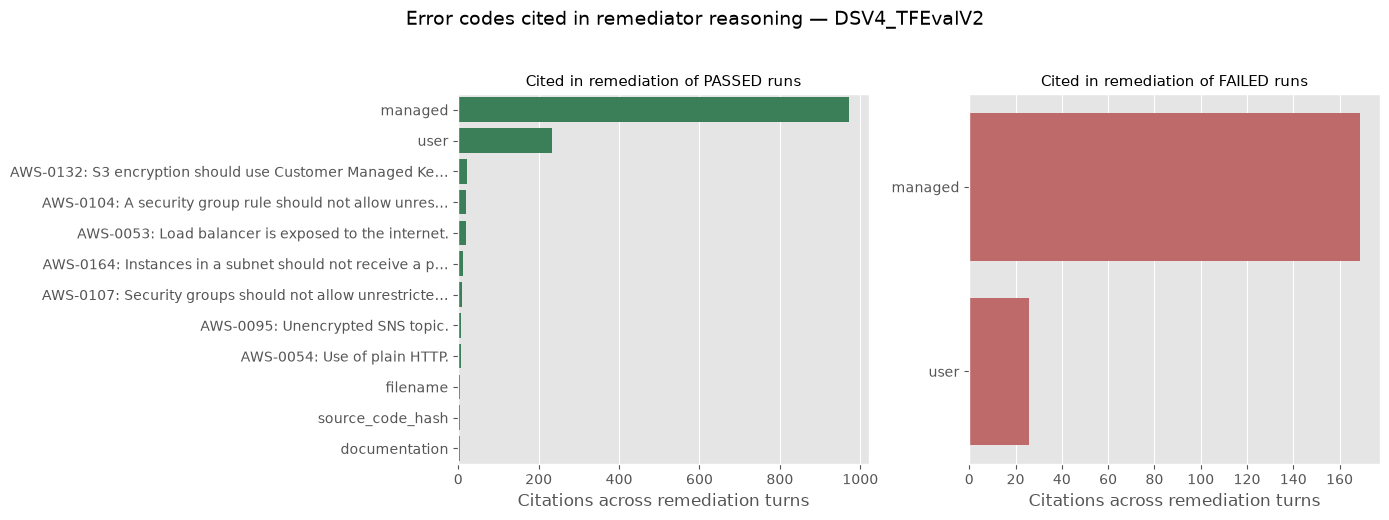


DSV4_TFEvalV2 — root-cause keyword themes in remediator reasoning:
  Passed runs: [('encryption', 67), ('security group', 50), ('deprecated', 49), ('public access', 33), ('customer managed key', 31), ('hardcoded', 12), ('self-contained', 12), ('circular dependency', 8)]
  Failed runs: [('encryption', 2), ('hardcoded', 1), ('deprecated', 1), ('public access', 1)]


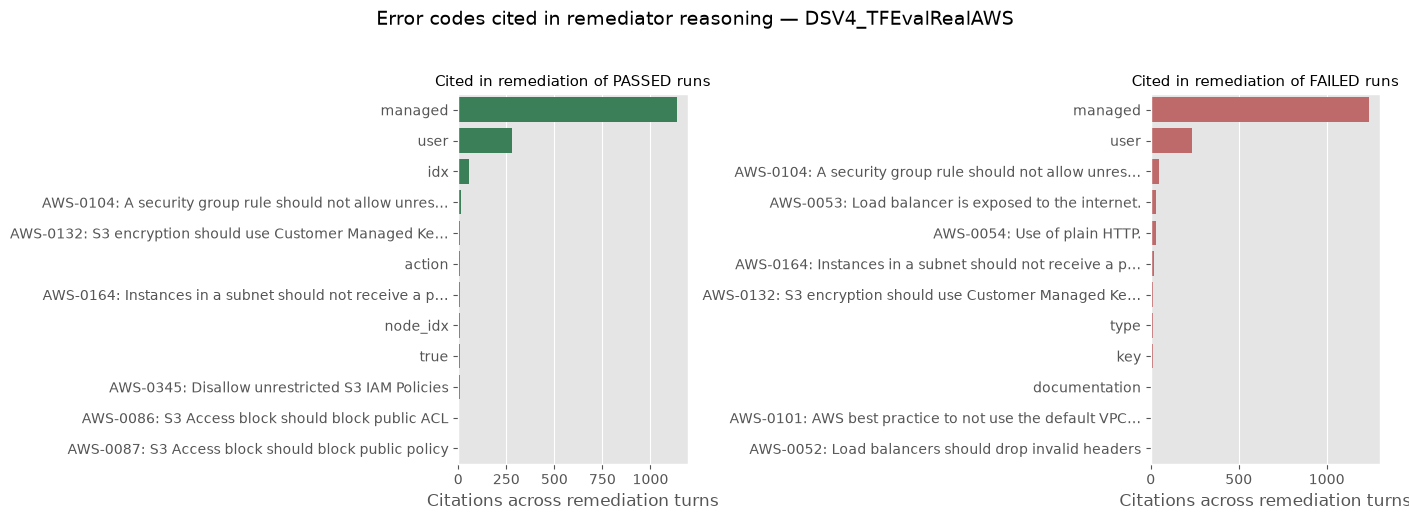


DSV4_TFEvalRealAWS — root-cause keyword themes in remediator reasoning:
  Passed runs: [('encryption', 52), ('deprecated', 43), ('security group', 41), ('public access', 25), ('hardcoded', 19), ('customer managed key', 17), ('self-contained', 10), ('type mismatch', 3)]
  Failed runs: [('encryption', 13), ('deprecated', 11), ('security group', 11), ('public access', 8), ('hardcoded', 6), ('customer managed key', 5), ('missing resource', 2), ('type mismatch', 1)]


In [23]:
# ── 15. What the Remediator Says It's Fixing ────────────────────────────────
# The remediator's own "Root Cause Analysis" / "Fix Objectives" text in
# remediator_history.txt cites the exact bracketed error codes it's
# addressing. Tallying those citations (separately for runs that ultimately
# PASSED vs FAILED) shows which error classes the remediator recognizes and
# handles confidently vs. which ones show up disproportionately in runs that
# never converge -- a rough proxy for "the remediator's blind spots."

ROOT_CAUSE_KEYWORDS = [
    "circular dependency", "deprecated", "hardcoded", "self-contained", "self-containment",
    "unused parameter", "missing resource", "iam permission", "trust policy",
    "encryption", "customer managed key", "public access", "security group",
    "dependson", "intrinsic function", "type mismatch", "not authorized",
]

def cited_codes_and_keywords(run_dir: Path) -> tuple:
    hist = run_dir / "remediator_history.txt"
    if not hist.exists():
        return Counter(), Counter()
    text = hist.read_text(errors="ignore")
    # Only look at [assistant] turns -- the [user] turns just re-paste the
    # template with injected `# ERROR:` comments, which would double-count
    # every code already captured from iteration_*.json.
    assistant_blocks = re.split(r"^\[assistant\]\s*$", text, flags=re.MULTILINE)[1:]
    assistant_text = "\n".join(assistant_blocks)
    codes = Counter(c for c in CODE_RE.findall(assistant_text) if GOOD_CODE_RE.match(c))
    low = assistant_text.lower()
    kws = Counter(kw for kw in ROOT_CAUSE_KEYWORDS if kw in low)
    return codes, kws

for model_name, df in merged_dataframes.items():
    if model_name not in RUN_COVERAGE or "final_validation_passed" not in df.columns:
        continue
    located_df = df[RUN_COVERAGE[model_name]].head(MEMORY_SAMPLE_LIMIT)
    if located_df.empty:
        continue

    cited_passed, cited_failed = Counter(), Counter()
    kw_passed, kw_failed = Counter(), Counter()
    for _, row in located_df.iterrows():
        run_dir = RUN_INDEX[row["run_id"]]
        codes, kws = cited_codes_and_keywords(run_dir)
        bucket_c = cited_passed if row["final_validation_passed"] else cited_failed
        bucket_k = kw_passed if row["final_validation_passed"] else kw_failed
        bucket_c.update(codes)
        bucket_k.update(kws)

    if not (cited_passed or cited_failed):
        continue

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, counter, title, color in [
        (axes[0], cited_passed, "Cited in remediation of PASSED runs", "seagreen"),
        (axes[1], cited_failed, "Cited in remediation of FAILED runs", "indianred"),
    ]:
        top = pd.DataFrame(counter.most_common(12), columns=["Code", "Count"])
        if top.empty:
            ax.text(0.5, 0.5, "No citations", ha="center", va="center")
            ax.set_axis_off()
            continue
        top["Label"] = top["Code"].apply(describe_code)
        sns.barplot(data=top, y="Label", x="Count", color=color, ax=ax)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("Citations across remediation turns")
        ax.set_ylabel("")
    fig.suptitle(f"Error codes cited in remediator reasoning — {model_name}", fontsize=14, y=1.03)
    plt.tight_layout()
    plt.show()

    print(f"\n{model_name} — root-cause keyword themes in remediator reasoning:")
    print(f"  Passed runs: {kw_passed.most_common(8)}")
    print(f"  Failed runs: {kw_failed.most_common(8)}")
